In [1]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows
import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
from scipy import stats

In [2]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import h5py
import hdf5plugin  # REQUIRED to have the compression plugins available
import numpy as np
from scipy import constants, interpolate
import copy
import glob
import re
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 1000)
from uvtools.plot import plot_antpos, plot_antclass
from hera_qm import ant_metrics, ant_class, xrfi
from hera_qm import ant_metrics, xrfi
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
from hera_filters import dspec
from IPython.display import display, HTML
import linsolve
import time
import argparse


lst="0h"
spw="low"
tstart = time.time()

filter_name="Main_lobe_20_mHz"

## load file names to calibrate

path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
path_data2="/net/sinatra/vault2/ntsikelelo/Data_H6C/"

def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data2+"*sum.uvh5"), key=numerical_sort)
uvh5name_diff = sorted(glob.glob(path_data2+"*diff.uvh5"), key=numerical_sort)

print("done loading data file names")



# parse omnical settings
OC_MAX_DIMS = int(os.environ.get("OC_MAX_DIMS", 4))
OC_MIN_DIM_SIZE = int(os.environ.get("OC_MIN_DIM_SIZE", 8))
OC_SKIP_OUTRIGGERS = os.environ.get("OC_SKIP_OUTRIGGERS", "FALSE").upper() == "TRUE"
OC_MIN_BL_LEN = float(os.environ.get("OC_MIN_BL_LEN", 1))
OC_MAX_BL_LEN = float(os.environ.get("OC_MAX_BL_LEN", 1e100))
OC_MAXITER = int(os.environ.get("OC_MAXITER", 50))
OC_MAX_RERUN = int(os.environ.get("OC_MAX_RERUN", 4))
OC_RERUN_MAXITER = int(os.environ.get("OC_MAXITER", 25))
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = float(os.environ.get("OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE", 1))
OC_USE_PRIOR_SOL = os.environ.get("OC_USE_PRIOR_SOL", "FALSE").upper() == "TRUE"
OC_PRIOR_SOL_FLAG_THRESH = float(os.environ.get("OC_PRIOR_SOL_FLAG_THRESH", .95))
OC_USE_GPU = os.environ.get("SAVE_RESULTS", "FALSE").upper() == "TRUE"

# parse RFI settings
RFI_DPSS_HALFWIDTH = float(os.environ.get("RFI_DPSS_HALFWIDTH", 300e-9))
RFI_NSIG = float(os.environ.get("RFI_NSIG", 4))




#set flag parameters, same as standard hera calibration pipepline 
    

# ant_metrics bounds for low correlation / dead antennas
am_corr_bad = (0, float(os.environ.get("AM_CORR_BAD", 0.3)))
am_corr_suspect = (float(os.environ.get("AM_CORR_BAD", 0.3)), float(os.environ.get("AM_CORR_SUSPECT", 0.5)))

# ant_metrics bounds for cross-polarized antennas
am_xpol_bad = (-1, float(os.environ.get("AM_XPOL_BAD", -0.1)))
am_xpol_suspect = (float(os.environ.get("AM_XPOL_BAD", -0.1)), float(os.environ.get("AM_XPOL_SUSPECT", 0)))

# bounds on solar altitude (in degrees)
good_solar_altitude = (-90, float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)))
suspect_solar_altitude = (float(os.environ.get("SUSPECT_SOLAR_ALTITUDE", 0)), 90)

# bounds on zeros in spectra
good_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_GOOD", 2)))
suspect_zeros_per_eo_spectrum = (0, int(os.environ.get("MAX_ZEROS_PER_EO_SPEC_SUSPECT", 8)))

# bounds on autocorrelation power
auto_power_good = (float(os.environ.get("AUTO_POWER_GOOD_LOW", 5)), float(os.environ.get("AUTO_POWER_GOOD_HIGH", 30)))
auto_power_suspect = (float(os.environ.get("AUTO_POWER_SUSPECT_LOW", 1)), float(os.environ.get("AUTO_POWER_SUSPECT_HIGH", 60)))

# bounds on autocorrelation slope
auto_slope_good = (float(os.environ.get("AUTO_SLOPE_GOOD_LOW", -0.4)), float(os.environ.get("AUTO_SLOPE_GOOD_HIGH", 0.4)))
auto_slope_suspect = (float(os.environ.get("AUTO_SLOPE_SUSPECT_LOW", -0.6)), float(os.environ.get("AUTO_SLOPE_SUSPECT_HIGH", 0.6)))

# bounds on autocorrelation RFI
auto_rfi_good = (0, float(os.environ.get("AUTO_RFI_GOOD", 1.5)))
auto_rfi_suspect = (0, float(os.environ.get("AUTO_RFI_SUSPECT", 2)))

# bounds on autocorrelation shape
auto_shape_good = (0, float(os.environ.get("AUTO_SHAPE_GOOD", 0.1)))
auto_shape_suspect = (0, float(os.environ.get("AUTO_SHAPE_SUSPECT", 0.2)))

# bound on per-xengine non-noiselike power in diff
bad_xengine_zcut = float(os.environ.get("BAD_XENGINE_ZCUT", 10.0))

# bounds on chi^2 per antenna in omnical
oc_cspa_good = (0, float(os.environ.get("OC_CSPA_GOOD", 2)))
oc_cspa_suspect = (0, float(os.environ.get("OC_CSPA_SUSPECT", 3)))

# print bounds
for bound in ['am_corr_bad', 'am_corr_suspect', 'am_xpol_bad', 'am_xpol_suspect', 
              'good_solar_altitude', 'suspect_solar_altitude',
              'good_zeros_per_eo_spectrum', 'suspect_zeros_per_eo_spectrum',
              'auto_power_good', 'auto_power_suspect', 'auto_slope_good', 'auto_slope_suspect',
              'auto_rfi_good', 'auto_rfi_suspect', 'auto_shape_good', 'auto_shape_suspect',
              'bad_xengine_zcut', 'oc_cspa_good', 'oc_cspa_suspect']:
    print(f'{bound} = {eval(bound)}')

# print settings
for setting in [ 'OC_MAX_DIMS', 'OC_MIN_DIM_SIZE', 'OC_SKIP_OUTRIGGERS', 
            'OC_MIN_BL_LEN', 'OC_MAX_BL_LEN', 'OC_MAXITER', 'OC_MAX_RERUN', 'OC_RERUN_MAXITER', 
            'OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE', 'OC_USE_PRIOR_SOL', 'OC_PRIOR_SOL_FLAG_THRESH', 
            'OC_USE_GPU', 'RFI_DPSS_HALFWIDTH', 'RFI_NSIG']:
    print(f'{setting} = {eval(setting)}')

#breakup the filtered data
hd = io.HERAData(path_data+"filtered_single_pol_combined_data_"+lst+"_"+spw+".uvh5")

n=0

if lst=="0h":
        n=0
   

if lst=="1h":
        n=1 
   

if lst=="2h":
        n=2
        
  
# for x in range (N): 
#     i=4*x+n
#     print(i)
#     hd_temp = io.HERAData(uvh5name[i])
#     times=hd_temp.times[0]

#     hd.read(times=times)        
#     data,_,_=hd.build_datacontainers()
#     hd_temp.read(frequencies=hd.freqs, times=times)
#     hd_temp.update(data=data)
#     hd_temp.write_uvh5("/net/sinatra/vault-ike/ntsikelelo/filtered_data/filtered_data_"+uvh5name[i][43:69], clobber=True)



    
    


done loading data file names
am_corr_bad = (0, 0.3)
am_corr_suspect = (0.3, 0.5)
am_xpol_bad = (-1, -0.1)
am_xpol_suspect = (-0.1, 0.0)
good_solar_altitude = (-90, 0.0)
suspect_solar_altitude = (0.0, 90)
good_zeros_per_eo_spectrum = (0, 2)
suspect_zeros_per_eo_spectrum = (0, 8)
auto_power_good = (5.0, 30.0)
auto_power_suspect = (1.0, 60.0)
auto_slope_good = (-0.4, 0.4)
auto_slope_suspect = (-0.6, 0.6)
auto_rfi_good = (0, 1.5)
auto_rfi_suspect = (0, 2.0)
auto_shape_good = (0, 0.1)
auto_shape_suspect = (0, 0.2)
bad_xengine_zcut = 10.0
oc_cspa_good = (0, 2.0)
oc_cspa_suspect = (0, 3.0)
OC_MAX_DIMS = 4
OC_MIN_DIM_SIZE = 8
OC_SKIP_OUTRIGGERS = False
OC_MIN_BL_LEN = 1.0
OC_MAX_BL_LEN = 1e+100
OC_MAXITER = 50
OC_MAX_RERUN = 4
OC_RERUN_MAXITER = 25
OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE = 1.0
OC_USE_PRIOR_SOL = False
OC_PRIOR_SOL_FLAG_THRESH = 0.95
OC_USE_GPU = False
RFI_DPSS_HALFWIDTH = 3e-07
RFI_NSIG = 4.0


In [3]:
x=0
i=4*x+n
print(i)
read_start = time.time()

# load data
##filter data when filter are used
hd = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/filtered_data/filtered_data_"+uvh5name[i][43:69])

SUM_FILE=uvh5name[i]
DIFF_FILE=uvh5name_diff[i]
hd_unfil = io.HERAData(SUM_FILE)
hd_diff = io.HERAData(DIFF_FILE)
times=hd_unfil.times[0:2]
freq_range=hd_unfil.freq_array ### might need to look this again

data_unfil, _, _ = hd_unfil.read(frequencies=freq_range, times=times)
diff_data, _, _ = hd_diff.read(frequencies=freq_range, times=times)
data, _, _ = hd.read(times=times[0]) #not setting the requency range yet
print(f'Finished loading data in {(time.time() - read_start) / 60:.2f} minutes.')
   

# Antenna classification step 

ants = sorted(set([ant for bl in hd.bls for ant in utils.split_bl(bl)]))
auto_bls = [bl for bl in data if (bl[0] == bl[1]) and (utils.split_pol(bl[2])[0] == utils.split_pol(bl[2])[1])]
antpols = sorted(set([ant[1] for ant in ants]))

am = ant_metrics.AntennaMetrics(SUM_FILE, DIFF_FILE, sum_data=data_unfil, diff_data=diff_data)
am.iterative_antenna_metrics_and_flagging(crossCut=am_xpol_bad[1], deadCut=am_corr_bad[1])
am.all_metrics = {}  # this saves time and disk by getting rid of per-iteration information we never use

# Turn ant metrics into classifications
totally_dead_ants = [ant for ant, i in am.xants.items() if i == -1]
am_totally_dead = ant_class.AntennaClassification(good=[ant for ant in ants if ant not in totally_dead_ants], bad=totally_dead_ants)
am_corr = ant_class.antenna_bounds_checker(am.final_metrics['corr'], bad=[am_corr_bad], suspect=[am_corr_suspect], good=[(0, 1)])
am_xpol = ant_class.antenna_bounds_checker(am.final_metrics['corrXPol'], bad=[am_xpol_bad], suspect=[am_xpol_suspect], good=[(-1, 1)])
ant_metrics_class = am_totally_dead + am_corr + am_xpol
if np.all([ant_metrics_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for ant_metrics.')

min_sun_alt = np.min(utils.get_sun_alt(hd.times))
solar_class = ant_class.antenna_bounds_checker({ant: min_sun_alt for ant in ants}, good=[good_solar_altitude], suspect=[suspect_solar_altitude])

zeros_class = ant_class.even_odd_zeros_checker(data_unfil, diff_data, good=good_zeros_per_eo_spectrum, suspect=suspect_zeros_per_eo_spectrum)
if np.all([zeros_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for too many even/odd zeros.')
    
auto_power_class = ant_class.auto_power_checker(data_unfil, good=auto_power_good, suspect=auto_power_suspect)
if np.all([(auto_power_class)[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged for bad autocorrelation power/slope.')
overall_class = auto_power_class  + zeros_class + ant_metrics_class + solar_class  

print("done with antenna classification")

## RFI Flagging 

def auto_bl_zscores(data, flag_array, cache={}):
    '''This function computes z-score arrays for each delay-filtered autocorrelation, normalized by the expected noise. 
    Flagged times/channels for the whole array are given 0 weight in filtering and are np.nan in the z-score.'''
    zscores = {}
    for bl in auto_bls:
        wgts = np.array(np.logical_not(flag_array), dtype=np.float64)
        model, _, _ = dspec.fourier_filter(data.freqs, data[bl], wgts, filter_centers=[0], filter_half_widths=[RFI_DPSS_HALFWIDTH], mode='dpss_solve',
                                            suppression_factors=[1e-9], eigenval_cutoff=[1e-9], cache=cache)
        res = data[bl] - model
        int_time = 24 * 3600 * np.median(np.diff(data.times))
        chan_res = np.median(np.diff(data.freqs))
        int_count = int(int_time * chan_res)
        sigma = np.abs(model) / np.sqrt(int_count / 2)
        zscores[bl] = res / sigma    
        zscores[bl][flag_array] = np.nan

    return zscores

def rfi_from_avg_autos(data, auto_bls_to_use, prior_flags=None, nsig=RFI_NSIG):
    '''Average together all baselines in auto_bls_to_use, then find an RFI mask by looking for outliers after DPSS filtering.'''
    
    # Compute int_count for all unflagged autocorrelations averaged together
    int_time = 24 * 3600 * np.median(np.diff(data.times_by_bl[auto_bls[0][0:2]]))
    chan_res = np.median(np.diff(data.freqs))
    int_count = int(int_time * chan_res) * len(auto_bls_to_use)
    avg_auto = {(-1, -1, 'ee'): np.mean([data[bl] for bl in auto_bls_to_use], axis=0)}
    
    # Flag RFI first with channel differences and then with DPSS
    antenna_flags, _ = xrfi.flag_autos(avg_auto, int_count=int_count, nsig=(RFI_NSIG * 5))
    if prior_flags is not None:
        antenna_flags[(-1, -1, 'ee')] = prior_flags
    _, rfi_flags = xrfi.flag_autos(avg_auto, int_count=int_count, flag_method='dpss_flagger',
                                   flags=antenna_flags, freqs=data.freqs, filter_centers=[0],
                                   filter_half_widths=[RFI_DPSS_HALFWIDTH], eigenval_cutoff=[1e-9], nsig=nsig)

    return rfi_flags    



antenna_flags, array_flags = xrfi.flag_autos(data_unfil, flag_method="channel_diff_flagger", nsig=RFI_NSIG * 5, 
                                             antenna_class=overall_class, flag_broadcast_thresh=.5)
for key in antenna_flags:
    antenna_flags[key] = array_flags
cache = {}
_, array_flags = xrfi.flag_autos(data_unfil, freqs=data_unfil.freqs, flag_method="dpss_flagger",
                                 nsig=RFI_NSIG, antenna_class=overall_class,
                                 filter_centers=[0], filter_half_widths=[RFI_DPSS_HALFWIDTH],
                                 eigenval_cutoff=[1e-9], flags=antenna_flags, mode='dpss_matrix', 
                                 cache=cache, flag_broadcast_thresh=.5)

xengine_diff_class = ant_class.non_noiselike_diff_by_xengine_checker(data_unfil, diff_data, flag_waterfall=array_flags, 
                                                                     antenna_class=overall_class, 
                                                                     xengine_chans=1, bad_xengine_zcut=bad_xengine_zcut)
overall_class += xengine_diff_class
if np.all([overall_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged after flagging non-noiselike diffs.')


# Iteratively develop RFI mask, excess RFI classification, and autocorrelation shape classification
stage = 1
rfi_flags = np.array(array_flags)
prior_end_states = set()
while True:
    print(stage)
    # compute DPSS-filtered z-scores with current array-wide RFI mask
    zscores = auto_bl_zscores(data_unfil, rfi_flags)
    rms = {bl: np.nanmean(zscores[bl]**2)**.5 if np.any(np.isfinite(zscores[bl])) else np.inf for bl in zscores}
    
    # figure out which autos to use for finding new set of flags
    candidate_autos = [bl for bl in auto_bls if overall_class[utils.split_bl(bl)[0]] != 'bad']
    if stage == 1:
        # use best half of the unflagged antennas
        med_rms = np.nanmedian([rms[bl] for bl in candidate_autos])
        autos_to_use = [bl for bl in candidate_autos if rms[bl] <= med_rms]
    elif stage == 2:
        # use all unflagged antennas which are auto RFI good, or the best half, whichever is larger
        med_rms = np.nanmedian([rms[bl] for bl in candidate_autos])
        best_half_autos = [bl for bl in candidate_autos if rms[bl] <= med_rms]
        good_autos = [bl for bl in candidate_autos if (overall_class[utils.split_bl(bl)[0]] != 'bad')
                      and (auto_rfi_class[utils.split_bl(bl)[0]] == 'good')]
        autos_to_use = (best_half_autos if len(best_half_autos) > len(good_autos) else good_autos)
    elif stage == 3:
        # use all unflagged antennas which are auto RFI good or suspect
        autos_to_use = [bl for bl in candidate_autos if (overall_class[utils.split_bl(bl)[0]] != 'bad')]

    # compute new RFI flags
    rfi_flags = rfi_from_avg_autos(data_unfil, autos_to_use)

    # perform auto shape and RFI classification
    overall_class = auto_power_class  + zeros_class + ant_metrics_class + solar_class + xengine_diff_class
    auto_rfi_class = ant_class.antenna_bounds_checker(rms, good=auto_rfi_good, suspect=auto_rfi_suspect, bad=(0, np.inf))
    overall_class += auto_rfi_class
    auto_shape_class = ant_class.auto_shape_checker(data_unfil, good=auto_shape_good, suspect=auto_shape_suspect,
                                                    flag_spectrum=np.sum(rfi_flags, axis=0).astype(bool), 
                                                    antenna_class=overall_class)
    overall_class += auto_shape_class
    
    # check for convergence by seeing whether we've previously gotten to this number of flagged antennas and channels
    if stage == 3:
        if (len(overall_class.bad_ants), np.sum(rfi_flags)) in prior_end_states:
            break
        prior_end_states.add((len(overall_class.bad_ants), np.sum(rfi_flags)))
    else:
        stage += 1


auto_class = auto_power_class + auto_rfi_class + auto_shape_class
if np.all([overall_class[utils.split_bl(bl)[0]] == 'bad' for bl in auto_bls]):
    raise ValueError('All antennas are flagged after flagging for bad autos power/slope/rfi/shape.')        


print("done with RFI flagging")


 ## Perform redundant calibration    

def classify_off_grid(reds, all_ants):
    '''Returns AntennaClassification of all_ants where good ants are in reds while bad ants are not.'''
    ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
    on_grid = [ant for ant in all_ants if ant in ants_in_reds]
    off_grid = [ant for ant in all_ants if ant not in ants_in_reds]
    return ant_class.AntennaClassification(good=on_grid, bad=off_grid)

def per_pol_filter_reds(reds, pols=['nn', 'ee'], **kwargs):
    '''Performs redcal filtering separately on polarizations (which might have different min_dim_size issues).'''
    return [red for pol in pols for red in redcal.filter_reds(copy.deepcopy(reds), pols=[pol], **kwargs)]  

def check_if_whole_pol_flagged(redcal_class, pols=['Jee', 'Jnn']):
    '''Checks if an entire polarization is flagged. If it is, returns True and marks all antennas as bad in redcal_class.'''
    if np.logical_or(*[np.all([redcal_class[ant] == 'bad' for ant in redcal_class.ants if ant[1] == pol]) for pol in pols]):
        print('An entire polarization has been flagged. Stopping redcal.')
        for ant in redcal_class:
            redcal_class[ant] = 'bad'
        return True
    return False    


def recheck_chisq(cspa, sol, cutoff, avg_alg, rfi_flags):
    '''Recompute chisq per ant without apparently bad antennas to see if any antennas get better.'''
    avg_cspa = {ant: avg_alg(np.where(rfi_flags, np.nan, cspa[ant])) for ant in cspa}
    sol2 = redcal.RedSol(sol.reds, gains={ant: sol[ant] for ant in avg_cspa if avg_cspa[ant] <= cutoff}, vis=sol.vis)
    new_chisq_per_ant = {ant: np.array(cspa[ant]) for ant in sol2.gains}
    if len(set([bl[2] for red in per_pol_filter_reds(sol2.reds, ants=sol2.gains.keys(), antpos=hd.data_antpos, **fr_settings) for bl in red])) >= 2:
        redcal.expand_omni_gains(sol2, sol2.reds, data, chisq_per_ant=new_chisq_per_ant)
    for ant in avg_cspa:
        if ant in new_chisq_per_ant:
            if np.any(np.isfinite(new_chisq_per_ant[ant])):
                if not np.all(np.isclose(new_chisq_per_ant[ant], 0)):
                    new_avg_cspa = avg_alg(np.where(rfi_flags, np.nan, cspa[ant]))
                    if new_avg_cspa > 0:
                        avg_cspa[ant] = np.min([avg_cspa[ant], new_avg_cspa])
    return avg_cspa

import ctypes
def malloc_trim():
    try:
        ctypes.CDLL('libc.so.6').malloc_trim(0) 
    except OSError:
        pass



# this enables better memory management on linux
def redundant_calibration (data, redcal_class, overall_class, reds, rfi_flags):

    redcal_start = time.time()
    rc_settings = {'max_dims': OC_MAX_DIMS, 'oc_conv_crit': 1e-10, 'gain': 0.4, 'run_logcal': False,
                   'oc_maxiter': OC_MAXITER, 'check_after': OC_MAXITER, 'use_gpu': OC_USE_GPU}
    
    if check_if_whole_pol_flagged(redcal_class):
        # skip redcal, initialize empty sol and meta 
        sol = redcal.RedSol(reds)
        meta = {'chisq': None, 'chisq_per_ant': None}
    else:    
            # perform first stage of redundant calibration 
            meta, sol = redcal.redundantly_calibrate(data, reds, **rc_settings)
        
            max_dly = np.max(np.abs(list(meta['fc_meta']['dlys'].values())))  # Needed for RFI delay-slope cal
            median_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1] * 5, np.nanmedian, rfi_flags)
        
             # remove particularly bad antennas (5x the bound on median, not mean)
            cspa_class = ant_class.antenna_bounds_checker(median_cspa, good=(oc_cspa_good[0], oc_cspa_suspect[1] * 5), bad=[(-np.inf, np.inf)])
            redcal_class += cspa_class
            print(f'Removing {cspa_class.bad_ants} for >5x high median chi^2.')
            for ant in cspa_class.bad_ants:
                print(f'\t{ant}: {median_cspa[ant]:.3f}')
    
    
            # iteratively rerun redundant calibration
    redcal_done = False
    rc_settings['oc_maxiter'] = rc_settings['check_after'] = OC_RERUN_MAXITER
    for i in range(OC_MAX_RERUN + 1-OC_MAX_RERUN ):
        # refilter reds and update classification to reflect new off-grid ants, if any
        reds = per_pol_filter_reds(reds, ex_ants=(overall_class + redcal_class).bad_ants, antpos=hd.data_antpos, **fr_settings)
        reds = sorted(reds, key=len, reverse=True)
        redcal_class += classify_off_grid(reds, ants)
        ants_in_reds = set([ant for red in reds for bl in red for ant in utils.split_bl(bl)])
        
        # check to see whether we're done
        if check_if_whole_pol_flagged(redcal_class) or redcal_done or (i == OC_MAX_RERUN):
            break
    
        # re-run redundant calibration using previous solution, updating bad and suspicious antennas
        meta, sol = redcal.redundantly_calibrate(data, reds, sol0=sol, **rc_settings)
        malloc_trim()
        
        # recompute chi^2 for bad antennas without bad antennas to make sure they are actually bad
        mean_cspa = recheck_chisq(meta['chisq_per_ant'], sol, oc_cspa_suspect[1], np.nanmean, rfi_flags)
        
        # remove bad antennas
        cspa_class = ant_class.antenna_bounds_checker(mean_cspa, good=oc_cspa_good, suspect=oc_cspa_suspect, bad=[(-np.inf, np.inf)])
        for ant in cspa_class.bad_ants:
            if mean_cspa[ant] < np.max(list(mean_cspa.values())) / OC_MAX_CHISQ_FLAGGING_DYNAMIC_RANGE:
                cspa_class[ant] = 'suspect'  # reclassify as suspect if they are much better than the worst antennas
        redcal_class += cspa_class
        print(f'Removing {cspa_class.bad_ants} for high mean unflagged chi^2.')
        for ant in cspa_class.bad_ants:
            print(f'\t{ant}: {mean_cspa[ant]:.3f}')
    
        if len(cspa_class.bad_ants) == 0:
            redcal_done = True  # no new antennas to flag
    
    print(f'Finished redcal in {(time.time() - redcal_start) / 60:.2f} minutes.')
    overall_class += redcal_class
    
    expanded_reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
    expanded_reds = per_pol_filter_reds(expanded_reds, ex_ants=(ant_metrics_class + solar_class + zeros_class + auto_class + xengine_diff_class).bad_ants,
                                        max_dims=OC_MAX_DIMS, min_dim_size=OC_MIN_DIM_SIZE)
    if OC_SKIP_OUTRIGGERS:
        expanded_reds = redcal.filter_reds(expanded_reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
    if len(sol.gains) > 0:
        redcal.expand_omni_vis(sol, expanded_reds, data, chisq=meta['chisq'], chisq_per_ant=meta['chisq_per_ant'])
    
    # now figure out flags, nsamples etc.
    omni_flags = {ant: (~np.isfinite(g)) | (ant in overall_class.bad_ants) for ant, g in sol.gains.items()}
    vissol_flags = datacontainer.RedDataContainer({bl: ~np.isfinite(v) for bl, v in sol.vis.items()}, reds=sol.vis.reds)
    single_nsamples_array = np.ones((len(data.times), len(data.freqs)), dtype=float)
    nsamples = datacontainer.DataContainer({bl: single_nsamples_array for bl in data})
    vissol_nsamples = redcal.count_redundant_nsamples(nsamples, [red for red in expanded_reds if red[0] in vissol_flags], 
                                                      good_ants=[ant for ant in overall_class if ant not in overall_class.bad_ants])
    for bl in vissol_flags:
        vissol_flags[bl][vissol_nsamples[bl] == 0] = True
    sol.make_sol_finite()
    
    return sol, meta, overall_class, vissol_flags



# figure out and filter reds and classify antennas based on whether or not they are on the main grid
fr_settings = {'max_dims': OC_MAX_DIMS, 'min_dim_size': OC_MIN_DIM_SIZE, 'min_bl_cut': OC_MIN_BL_LEN, 'max_bl_cut': OC_MAX_BL_LEN}
reds = redcal.get_reds(hd.data_antpos, pols=['ee', 'nn'], pol_mode='2pol')
reds = per_pol_filter_reds(reds, ex_ants=overall_class.bad_ants, antpos=hd.data_antpos, **fr_settings)
if OC_SKIP_OUTRIGGERS:
    reds = redcal.filter_reds(reds, ex_ants=[ant for ant in ants if ant[0] >= 320])
redcal_class = classify_off_grid(reds, ants) 


indexfreq=np.where( (hd.freqs[0]<=freq_range) & (freq_range <=hd.freqs[-1]))[0]    
rfi_flags_freq_select=rfi_flags[0,indexfreq[0]-1:indexfreq[-1]]    
sol, meta, overall_class, vissol_flags=redundant_calibration (data, redcal_class, overall_class, reds, rfi_flags_freq_select)  

np.save(path_data+"gains/gains_"+filter_name+"_redcal_"+uvh5name[i][43:69]+".npy",sol.gains)

chis_redcal=np.where(rfi_flags_freq_select, np.nan, meta['chisq']['Jnn']).ravel()
np.save(path_data+"chisq/chisq_"+filter_name+"_redcal_"+uvh5name[i][43:69]+".npy",chis_redcal)
hd.update(data=sol.vis)
hd.write_uvh5(path_data+"redundant_"+filter_name+"_cal_data_temp.uvh5", clobber=True)

print("done with redundant calibration")


0
Finished loading data in 0.93 minutes.


All-NaN slice encountered


done with antenna classification


Mean of empty slice
divide by zero encountered in divide


1


invalid value encountered in divide
invalid value encountered in divide
Mean of empty slice


2
3
3
done with RFI flagging
Removing set() for >5x high median chi^2.
Removing set() for high mean unflagged chi^2.
Finished redcal in 3.23 minutes.
File exists; clobbering
done with redundant calibration


In [4]:
### Perform abscal NOTE that flags along freqs are not dealt with 


def produce_model_data(mode="full_sky_model", freqs=freq_range, times=times):
    hdm_gleam = io.HERAData(path_data+"Filtered_model_gleam_vis_expanded_"+lst+"_"+spw+".uvh5")
    hdm_gleam.read(times=times, frequencies=freqs)
    model_data_gleam,_,_=hdm_gleam.build_datacontainers()
    
    if mode=="full_sky_model":
        hdm_diffuse = io.HERAData(path_data+"Filtered_model_diffuse_vis_expanded_"+lst+"_"+spw+".uvh5")
        hdm_diffuse.read(times=times, frequencies=freqs)
        model_data_diffuse,_,_=hdm_diffuse.build_datacontainers()
    
    if mode=="gleam_only":
        model_data=copy.deepcopy(model_data_gleam)
    if mode=="full_sky_model":
        model_data=copy.deepcopy(model_data_gleam)
        for bl in model_data:
            model_data[bl]=model_data[bl]+model_data_diffuse[bl]
    return model_data 
hdm_gleam = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/Filtered_model_gleam_vis_expanded_"+lst+"_"+spw+".uvh5")
freq_range_reduced=freq_range[np.where( (hdm_gleam.freqs[0]<=freq_range) & (freq_range <=hdm_gleam.freqs[-1]))]
indexfreq=np.where( (hdm_gleam.freqs[0]<=freq_range) & (freq_range <=hdm_gleam.freqs[-1]))[0]
model_data_expanded_data=produce_model_data(mode="gleam_only", freqs=freq_range_reduced, times=times[0])

reds_here = redcal.get_reds(hd.data_antpos, pols=['nn'], pol_mode='1pol')
reds_filtered = per_pol_filter_reds(reds_here, ex_ants=overall_class.bad_ants, antpos=hd.data_antpos, **fr_settings)
all_bls=[]
for rg in reds_filtered:
            for bl in rg:
                all_bls.append(bl)

matched_bls=[]
for key in all_bls:
    if key in model_data_expanded_data.keys():
        matched_bls.append(key)

hd_cal= io.HERAData(path_data+"redundant_"+filter_name+"_cal_data_temp.uvh5")
hd_cal.read(bls=matched_bls, frequencies=freq_range_reduced, times=times[0])
redcal_data,_,_=hd_cal.build_datacontainers()


hd_data= io.HERAData(SUM_FILE)
hd_data.read(bls=matched_bls, frequencies=freq_range_reduced, times=times[0])
data_reduced,_,_=hd_data.build_datacontainers()

def abscal_post_red_cal(data, model_data, redcal_data, redcal_gains, rfi_flags, hd):
    antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
    antpos_d = dict(zip(ants, antpos))
    #choose only baselines in data in model
    model_data_modi=copy.deepcopy(redcal_data)
    for k in redcal_data.keys():
            model_data_modi[k]=np.array(model_data[k])
    
    gain_cal_pol={}
    for k in redcal_gains:
        if k[1]=='Jnn':
            gain_cal_pol[k]=redcal_gains[k]
    
    rc_flags = {k: np.zeros_like(gain_cal_pol[k], dtype=bool) for k in gain_cal_pol}

    #get waterfall flags
    # there is a per frequency slove so rfi should not be a problem
    for ant in rc_flags:
        rc_flags[ant]=rfi_flags
           

        
    noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}
    n_cut=0
    for k in noise_wgts:

        blvec = (antpos[np.where(ants==k[0])][0] - antpos[np.where(ants==k[1])][0])

        bl_len_EW = np.abs(blvec[0])

        if bl_len_EW <30: 
            n_cut+=1

            noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40
    # calibration with lincal gains

    print("number of baseline cuts in "+str(n_cut))
    calibrated_data = copy.deepcopy(redcal_data)
    calibrated_data_filtered=copy.deepcopy(redcal_data)
    
    #calibrated data gets modified but it is not fully calibrated!
    abscal_gains = abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)
    
    total_gains = abscal.merge_gains([gain_cal_pol, abscal_gains])
    calibrated_data_final = copy.deepcopy(data)
    abscal.calibrate_in_place(calibrated_data_final, total_gains)
    
    abscal.calibrate_in_place(calibrated_data_filtered, abscal_gains)

    residual_data_filtered=copy.deepcopy(redcal_data)
    for bl in residual_data_filtered:
        residual_data_filtered[bl]=calibrated_data_filtered[bl]-model_data_modi[bl]
    
    # data_final_zero_padded=copy.deepcopy(data)
    # model_data_zero_padded=copy.deepcopy(model_data_modi)
    # for bl in data_final_zero_padded:

    #     data_final_zero_padded[bl][0,:][rfi_flags]=np.zeros(data_final_zero_padded[bl][0,:][rfi_flags].shape)
    #     model_data_zero_padded[bl][0,:][rfi_flags]=np.zeros(data_final_zero_padded[bl][0,:][rfi_flags].shape)
    
    # abs_chisq, nObs, _, _ = utils.chisq(data_final_zero_padded, model_data_zero_padded, gains=total_gains, data_wgts=noise_wgts)
    # chisq_dof = nObs.mean() - len(abscal_gains)
    # red_chisq = abs_chisq / chisq_dof
    
    return calibrated_data_final, total_gains, residual_data_filtered
    
redcal_gains={}
for key in sol.gains:
    redcal_gains[key]=sol.gains[key][0,:]



model_data_expanded_data_full=produce_model_data(mode="full_sky_model", freqs=freq_range_reduced, times=times[0])
calibrated_data_final_full, total_gains_full, calibrated_data_final_full_filtered=abscal_post_red_cal(data_reduced, model_data_expanded_data_full, redcal_data, redcal_gains, rfi_flags[0,indexfreq[0]-1:indexfreq[-1]], hd)

#calibrated_data_final_gleam, total_gains_gleam, calibrated_data_final_gleam_filtered=abscal_post_red_cal(data_reduced, model_data_expanded_data, redcal_data, redcal_gains, rfi_flags[0,indexfreq[0]-1:indexfreq[-1]], hd)
    

## FLagged data




 

number of baseline cuts in 560


In [5]:
def flag_data_and_gains(calibrated_data_final, total_gains, rfi_flags):

    data_flagged_redcal=copy.deepcopy(calibrated_data_final)
    for bls in data_flagged_redcal:
       
        if not overall_class[utils.split_bl(bls)[0]]=='bad':
            data_flagged_redcal[bls]=np.array(calibrated_data_final[bls])
            data_flagged_redcal[bls][0,:][np.where(rfi_flags==True)]=np.nan
                
            
        else:
           
            data_flagged_redcal[bls]=np.ones(calibrated_data_final[bls].shape)*np.nan
    total_gains_flagged=copy.deepcopy(total_gains)
    for ant in total_gains_flagged:
        
        if not overall_class[utils.split_bl(bls)[0]]=='bad':
            total_gains_flagged[ant][0,:][np.where(rfi_flags==True)]=np.nan
                    
                
        else:
               
            total_gains_flagged[ant]=np.ones(total_gains_flagged[ant].shape)*np.nan            
    return data_flagged_redcal, total_gains_flagged

# data_flagged_redcal_gleam, total_gains_flagged_gleam=flag_data_and_gains(calibrated_data_final_gleam, total_gains_gleam, rfi_flags[0,indexfreq[0]-1:indexfreq[-1]])

# data_flagged_redcal_gleam_filtered, total_gains_flagged_gleam=flag_data_and_gains(calibrated_data_final_gleam_filtered, total_gains_gleam, rfi_flags[0,indexfreq[0]-1:indexfreq[-1]])

# data_flagged_redcal_full_filtered, total_gains_flagged_full=flag_data_and_gains(calibrated_data_final_full_filtered, total_gains_full, rfi_flags[0,indexfreq[0]-1:indexfreq[-1]])

data_flagged_redcal_full, total_gains_flagged_full=flag_data_and_gains(calibrated_data_final_full, total_gains_full, rfi_flags[0,indexfreq[0]-1:indexfreq[-1]])

# ## save data: gains and calibrated vis

# np.save(path_data+"gains/gains_"+filter_name+"_gleam_flagged_abscal"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",total_gains_flagged_gleam)
# np.save(path_data+"gains/gains_"+filter_name+"_full_flagged_abscal"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",total_gains_flagged_full)

# np.save(path_data+"gains/gains_"+filter_name+"_gleam_abscal"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",total_gains_gleam)
# np.save(path_data+"gains/gains_"+filter_name+"_full_abscal"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy",total_gains_full)

# bls=reds[0]
# cal_full={}
# for bl in bls:
#     if bl in data_flagged_redcal_full:
#         cal_full[bl]=data_flagged_redcal_full[bl]

# cal_full_filtered={}
# for bl in bls:
#     if bl in data_flagged_redcal_full_filtered:
#         cal_full_filtered[bl]=data_flagged_redcal_full_filtered[bl]

# cal_gleam_filtered={}
# for bl in bls:
#     if bl in data_flagged_redcal_gleam_filtered:
#         cal_gleam_filtered[bl]=data_flagged_redcal_gleam_filtered[bl] 

# cal_gleam={}
# for bl in bls:
#     if bl in data_flagged_redcal_gleam:
#         cal_gleam[bl]=data_flagged_redcal_gleam[bl]         
        
# np.save(path_data+"abs_calibrated_data_"+filter_name+"_full_"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", cal_full)
# np.save(path_data+"abs_calibrated_data_"+filter_name+"_full_filtered_"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", cal_full_filtered)

# np.save(path_data+"abs_calibrated_data_"+filter_name+"_gleam_"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", cal_gleam)
# np.save(path_data+"abs_calibrated_data_"+filter_name+"_gleam_filtered_"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", cal_gleam_filtered)
# print("done with file!")


In [20]:
bls=[]
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))
cal_full={}
bls_length=[]
for bl in data_flagged_redcal_full:
        blvec = (antpos[np.where(ants==bl[0])] - antpos[np.where(ants==bl[1])])
        if np.linalg.norm(blvec)-14<2:
    
            bls.append(bl)
             
        # cal_full[bl]=data_flagged_redcal_full[bl]


In [21]:
len(bls), len(reds[0])

(91, 42)

In [26]:



# now average all baselines within each group
def average_all_baselines_within_group(cal_data, hd, reds):
    antpos, ants = hd.get_ENU_antpos()
    antpos_dict = dict(zip(ants, antpos))
    
    bl_lens, bl_groups = [], []
    for red in reds:
        # get the baseline length of this redundant group
        bl = red[0]
        bl_len = np.linalg.norm(antpos_dict[bl[1]] - antpos_dict[bl[0]])
        # check if this bl_len exists
        if np.isclose(bl_len, bl_lens, atol=1).any():
            bl_groups[-1].extend(red)
        else:
            bl_groups.append(red)
            bl_lens.append(bl_len)


    
    N_t=1
    cal_wedge = np.zeros((N_t,len(bl_groups), hd.Nfreqs, hd.Npols), dtype=np.complex128)
    

    for i, bl_group in enumerate(bl_groups):
        for j, pol in enumerate(hd.get_pols()):
            if bl in cal_data:
                print(bl)
                cal_wedge[:,i, :, j] = np.mean([cal_data[bl] for bl in bl_group], axis=0)
    return cal_wedge          
        


# # now take the FFT across frequency: cut the edge channels
# cal_wedge_fft, delays = hc.vis_clean.fft_data(cal_wedge, np.diff(freqs)[0], axis=2,
#                                               edgecut_low=5, edgecut_hi=5, window='bh')
# mdl_wedge_fft, delays = hc.vis_clean.fft_data(mdl_wedge, np.diff(freqs)[0], axis=2,
#                                               edgecut_low=5, edgecut_hi=5, window='bh')  

#np.save(path_data+"cal_wedge_abs_calibrated_data_"+filter_name+"_gleam_"+uvh5name[i][43:69]+"_"+lst+"_"+spw+".npy", average_all_baselines_within_group(data_flagged_redcal_full, hd))
        

In [27]:
x=average_all_baselines_within_group(data_flagged_redcal_full, hd, reds)

In [22]:
len(bl_groups)

140

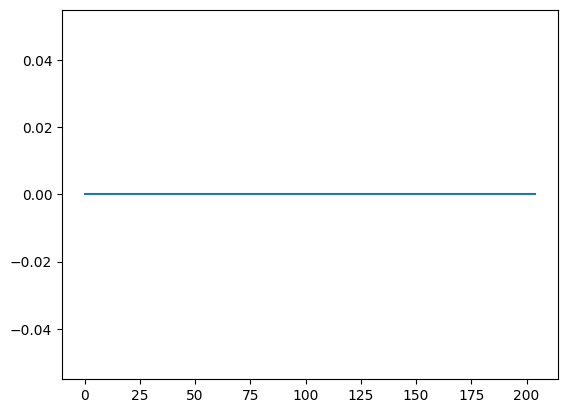

In [18]:
plt.plot(np.abs(x[0,0,:,0]))

In [20]:
np.max(x)

np.complex128(0j)

In [31]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_final_"+lst+"_"+spw+".uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)
freqs = uvd1.freq_array*1e-6

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [46]:
def plot_redundant_abs(start=0, N=10, freqs=freqs, cal_data="", title_name=""):
    for n in range (N):
        i=n+start
        for bls in cal_data:

            plt.semilogy(freqs[50:-1],np.abs(cal_data[bls][0][50:-1]))
    plt.title(title_name)
    plt.xlabel("Freq [MHz]")
    plt.ylabel("|V|[Jy]")

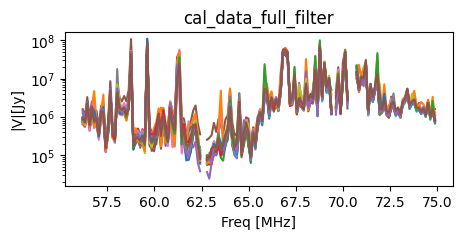

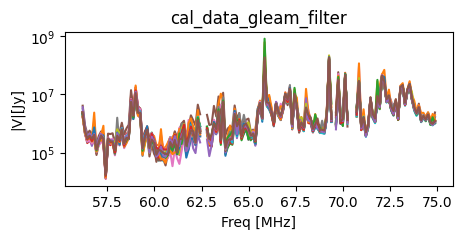

In [47]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_full, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_gleam, title_name="cal_data_gleam_filter")


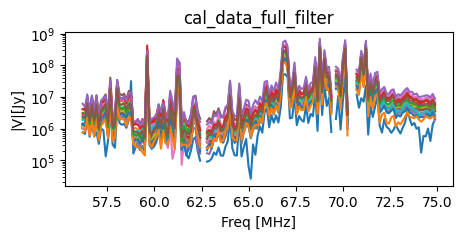

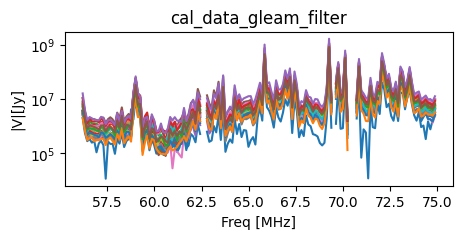

In [48]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_full_filtered, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=1, freqs=freqs, cal_data=cal_gleam_filtered, title_name="cal_data_gleam_filter")

In [37]:
cal_full[(np.int32(5),
  np.int32(16),
  'nn')]

array([[            nan+0.00000000e+00j, -5.02805499e+05-3.01622894e+05j,
        -3.47053848e+05-4.33288636e+05j,  7.52865743e+05-5.64829368e+05j,
        -8.32433306e+05+1.94613788e+05j, -1.57330562e+06-1.74092393e+06j,
         1.61844770e+06+2.42128810e+05j, -1.87134656e+05-1.92512913e+04j,
         8.31510267e+04+2.66736256e+05j, -1.90922076e+05+3.89618082e+04j,
        -2.34684519e+05+6.70102118e+04j, -2.15601117e+05-2.38870360e+05j,
        -2.98655526e+05+4.48618205e+04j, -2.78905240e+05-1.66383736e+05j,
        -2.63508981e+05-2.37612748e+05j, -7.06957677e+05-6.54895989e+05j,
        -1.07217643e+06-7.88652698e+05j, -1.38420582e+05-1.56111997e+05j,
        -3.38805115e+05+1.56465420e+05j, -2.17482377e+06+6.38490919e+05j,
        -3.73069729e+05+1.29303290e+05j, -5.24603674e+05+1.57608614e+05j,
        -3.46580300e+05+1.67096467e+05j, -1.74298820e+06+8.93664711e+05j,
        -4.16946542e+05+1.82331943e+05j, -4.99207305e+05+7.17914024e+05j,
         7.70659303e+05+1.64424763e+06

In [3]:
import glob
import re
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"
def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data+"*sum.uvh5"), key=numerical_sort)
# files_diff=files = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [4]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read(Model_complete_file, read_data=False)  

antpos=uvd1.antenna_positions
ants=uvd1.antenna_numbers
antpos_d = dict(zip(ants, antpos))
freqs = uvd1.freq_array[np.where((uvd1.freq_array>150e6) & (uvd1.freq_array<175e6))]

#make redundant groups model        
reds = hc.redcal.get_pos_reds(antpos_d, include_autos=True)

In [5]:
Model_complete_file = uvh5name[0]
uvd1 = UVData()
uvd1.read("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_final.uvh5", read_data=False)
lsts=np.rad2deg(np.unique(uvd1.lst_array))*(24/360)

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [6]:
N=275
def extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, N=N):
    cal_all_data=[]
    for i in range(N):
        cal_data = np.load(file_name+uvh5name[4*i][43:69]+".npy", allow_pickle=True).item()
        # print(cal_data)
        cal_all_data.append(cal_data) 
    return cal_all_data        

In [7]:

filter_name="Notch_filter_40_mHz"

In [8]:
cal_data_full=extrac_cal_data(file_name=path_data+"abs_calibrated_data_full_", uvh5name=uvh5name, N=N)

In [9]:
cal_data_full_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_full_", uvh5name=uvh5name, N=N)

In [10]:
cal_data_gleam_filter=extrac_cal_data(file_name=path_data+"abs_calibrated_data_"+filter_name+"_gleam_", uvh5name=uvh5name, N=N)

In [11]:
cal_data_gleam=extrac_cal_data(file_name=path_data+"abs_calibrated_data_gleam_", uvh5name=uvh5name, N=N)

In [12]:
hd_gleam_model = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_final.uvh5")
hd_gleam_model.read()
data_gleam,_,_=hd_gleam_model.build_datacontainers()

hd_gleam_model = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/diffuse_model_final.uvh5")
hd_gleam_model.read()
data_diffuse,_,_=hd_gleam_model.build_datacontainers()

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.
antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.
antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.
antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [13]:
bls=reds[0]
model_bls=[]
for bl in bls:
    bls_yy=(bl[0],bl[1],'yy')
    if bls_yy in data_diffuse:
        model_bls.append(bls_yy)
    

In [14]:

def plot_redundant_abs(start=0, N=10, freqs=freqs, cal_data=cal_data_full, title_name=""):
    for n in range (N):
        i=n+start
        for bls in cal_data[i]:

            plt.semilogy(freqs[50:-1],np.abs(cal_data[i][bls][0][50:-1]))
    plt.title(title_name)
    plt.xlabel("Freq [MHz]")
    plt.ylabel("|V|[Jy]")

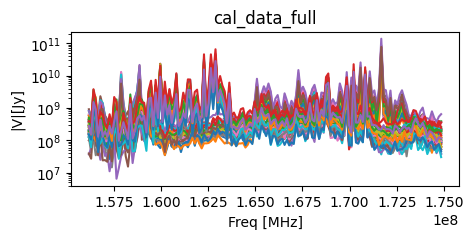

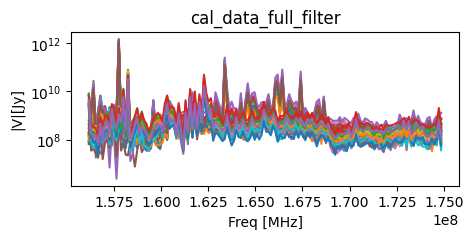

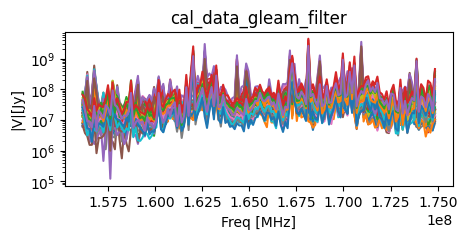

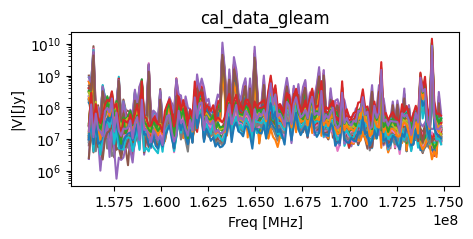

In [15]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=2, freqs=freqs, cal_data=cal_data_full, title_name="cal_data_full")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=2, freqs=freqs, cal_data=cal_data_full_filter, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=2, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="cal_data_gleam_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=0, N=2, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam")

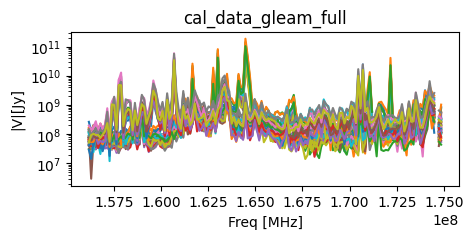

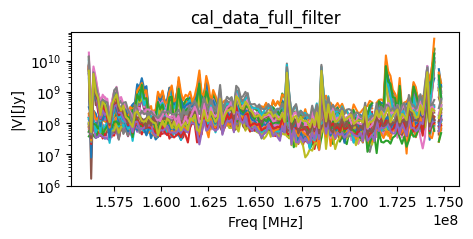

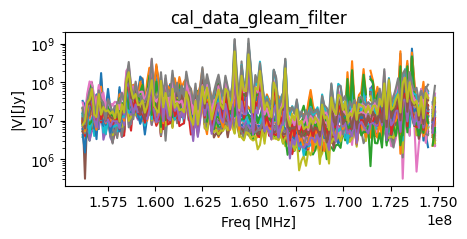

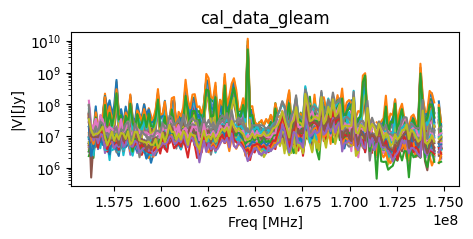

In [16]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=6, N=2, freqs=freqs, cal_data=cal_data_full, title_name="cal_data_gleam_full")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=6, N=2, freqs=freqs, cal_data=cal_data_full_filter, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=6, N=2, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="cal_data_gleam_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=6, N=2, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam")

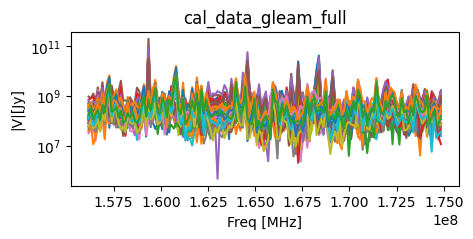

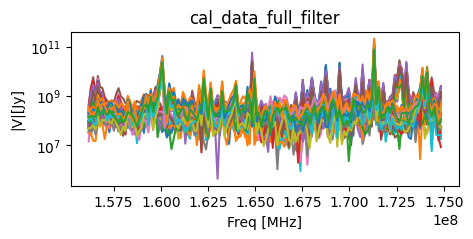

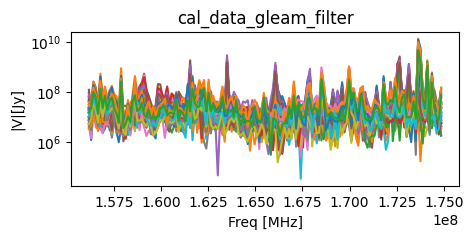

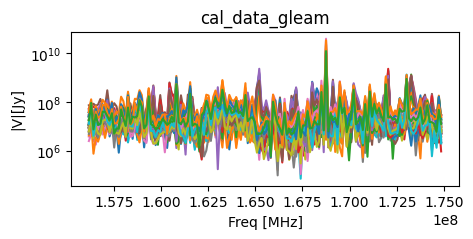

In [17]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=2, freqs=freqs, cal_data=cal_data_full, title_name="cal_data_gleam_full")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=2, freqs=freqs, cal_data=cal_data_full_filter, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=2, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="cal_data_gleam_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=60, N=2, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam")

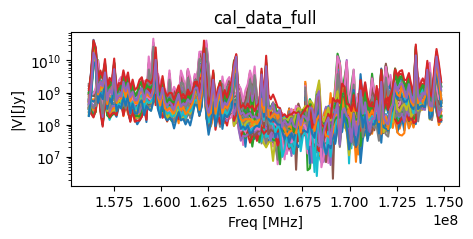

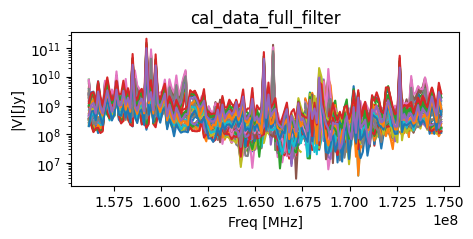

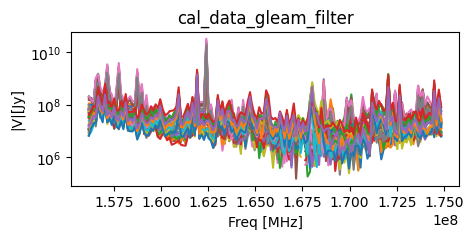

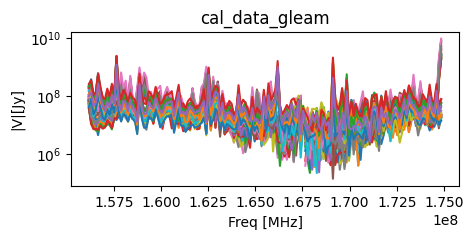

In [18]:
plt.figure(figsize=(5,2))
plot_redundant_abs(start=90, N=2, freqs=freqs, cal_data=cal_data_full, title_name="cal_data_full")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=90, N=2, freqs=freqs, cal_data=cal_data_full_filter, title_name="cal_data_full_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=90, N=2, freqs=freqs, cal_data=cal_data_gleam_filter, title_name="cal_data_gleam_filter")

plt.figure(figsize=(5,2))
plot_redundant_abs(start=90, N=2, freqs=freqs, cal_data=cal_data_gleam, title_name="cal_data_gleam")

In [ ]:
raw_data=[]
for i in range (10):
    hd_data=io.HERAData("/net/sinatra/vault-ike/ntsikelelo/filtered_data/raw_data_vis_"+uvh5name[4*(i+100)][43:69])

    hd_data.read()
    data_raw,_,_=hd_data.build_datacontainers()
    raw_data.append(data_raw)

In [ ]:
lsts[100]

In [ ]:
def calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_full_abscal_", n_time=10, n_start=0, freqs=freqs, plot_cal_data=True):
    cal_data=[]
    for n in range(n_time):
        i=n
        gains_per_time=np.load(path_data+gains_name+uvh5name[4*(i+n_start)][43:69]+".npy",allow_pickle=True).item()
        data_cal=copy.deepcopy(data[i])
        hc.apply_cal.calibrate_in_place(data_cal, gains_per_time)
        cal_data.append(data_cal)
    if plot_cal_data:
        plt.figure()
        for bl in data_cal.keys():
                plt.semilogy(freqs[50:-1],np.abs(cal_data[i][bl][0, 50:-1]))
                # plt.semilogy(freqs[50:-1],np.abs(cal_data[i][bl][1, 50:-1]))
     
    return cal_data  

In [ ]:
cal_data_full_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_full_abscal", n_time=10, n_start=0, freqs=freqs, plot_cal_data=True)
cal_data_full_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_full_abscal", n_time=10, n_start=90, freqs=freqs, plot_cal_data=True)

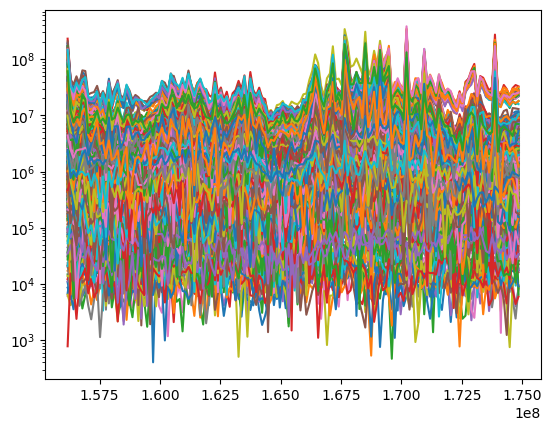

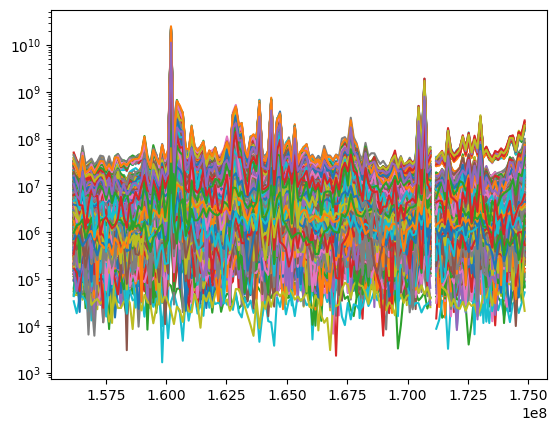

In [22]:
cal_data_gleam_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_gleam_abscal", n_time=8, n_start=0, freqs=freqs, plot_cal_data=True)
cal_data_gleam_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_gleam_abscal", n_time=10, n_start=20, freqs=freqs, plot_cal_data=True)

invalid value encountered in divide
invalid value encountered in divide


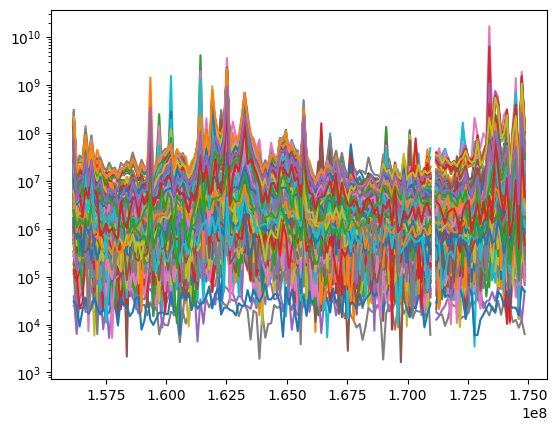

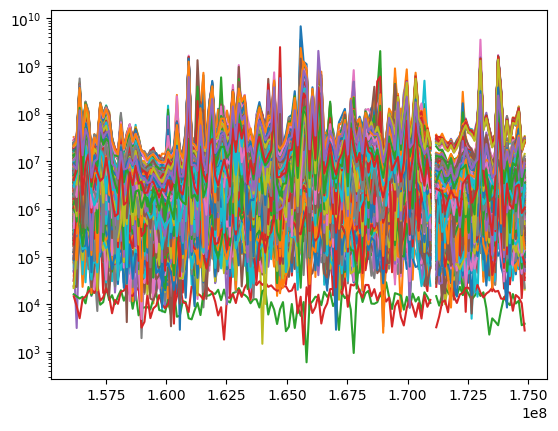

In [23]:
cal_data_gleam_filter_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_Notch_filter_40_mHz_gleam_flagged_abscal", n_time=10, n_start=0, freqs=freqs, plot_cal_data=True)
cal_data_gleam_filter_LST=calibrate_LST_interest_with_gains(data=raw_data, gains_name="gains/gains_Notch_filter_40_mHz_gleam_flagged_abscal", n_time=10, n_start=90, freqs=freqs, plot_cal_data=True)

In [24]:
def calculate_average_visility_amplitude(start=0, N=10, cal_data=cal_data_full):
    data_temp=[]
    for n in range (N):
        i=n+start
        for bls in cal_data[i]:
    
            data_temp.append(np.mean(np.abs(cal_data[i][bls]), axis=0)[50:-1])
    data_temp=np.array(data_temp)
    return np.nanmean(data_temp, axis=0)

In [25]:
len(cal_data_full)

275

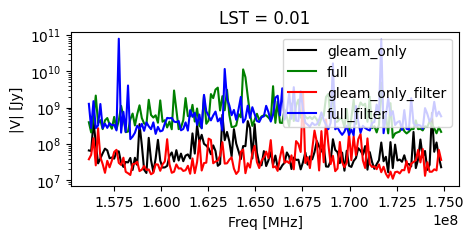

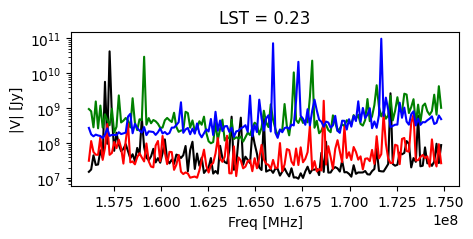

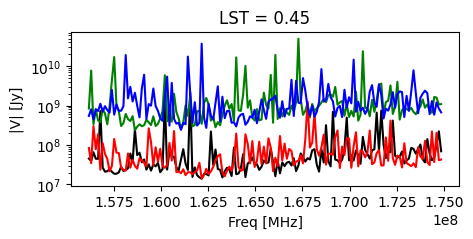

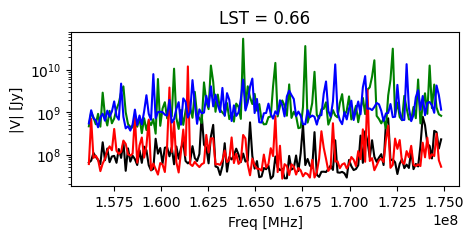

In [26]:
for n in range (4):
    i=n*10
    plt.figure(figsize=(5,2))
    gleam_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam)
    full_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full)
    gleam_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam_filter)
    full_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full_filter)
    #plt.semilogy(freqs[50:-1], np.mean(np.abs((data_gleam[model_bls[0]]+data_diffuse[model_bls[0]])[i:(i+1)*10,50:-1]), axis=0),'m', label="model")
    plt.semilogy(freqs[50:-1], gleam_average,'k', label="gleam_only")
    plt.semilogy(freqs[50:-1], full_average,'g', label="full")
    plt.semilogy(freqs[50:-1], gleam_average_filter,'r', label="gleam_only_filter")
    plt.semilogy(freqs[50:-1], full_average_filter,'b', label="full_filter")
    
    plt.xlabel("Freq [MHz]")
    plt.ylabel("|V| [Jy]")
    if i==0:
        plt.legend()
    plt.title("LST = "+str(np.round(lsts[i],2)))
    

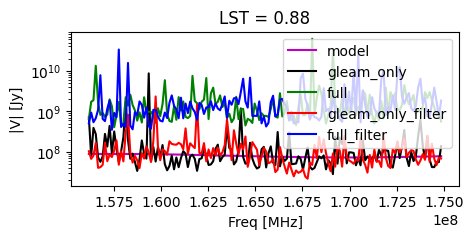

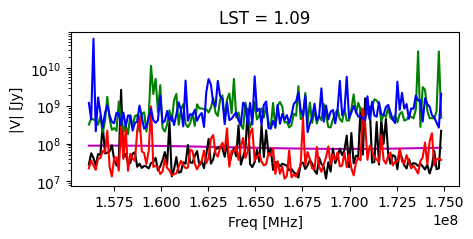

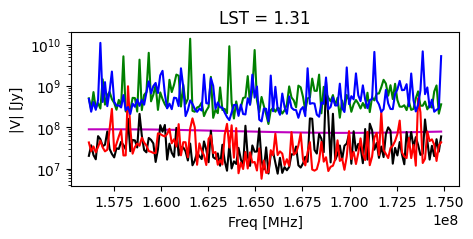

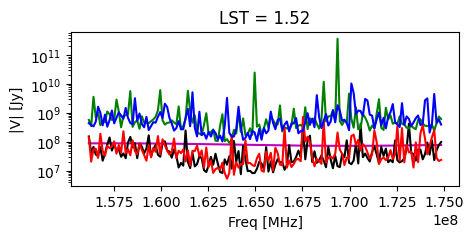

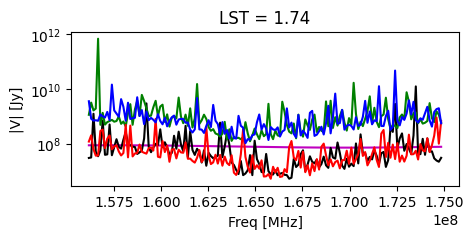

In [27]:
for n in range (5):
    i=(n+4)*10
    plt.figure(figsize=(5,2))
    gleam_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam)
    full_average=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full)
    gleam_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_gleam_filter)
    full_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full_filter)
    full_average_filter=calculate_average_visility_amplitude(start=i, N=10, cal_data=cal_data_full_filter)
    plt.semilogy(freqs[50:-1], np.mean(np.abs((data_gleam[model_bls[0]]+data_diffuse[model_bls[0]])[i:(i+1)*10,50:-1]), axis=0),'m', label="model")
    plt.semilogy(freqs[50:-1], gleam_average,'k', label="gleam_only")
    plt.semilogy(freqs[50:-1], full_average,'g', label="full")
    plt.semilogy(freqs[50:-1], gleam_average_filter,'r', label="gleam_only_filter")
    plt.semilogy(freqs[50:-1], full_average_filter,'b', label="full_filter")
    plt.xlabel("Freq [MHz]")
    plt.ylabel("|V| [Jy]")
    if n==0:
        plt.legend()
    plt.title("LST = "+str(np.round(lsts[i],2)))

In [28]:
cross_all_time=[]
for t in range (1):
    bls=[]
    for key in cal_data_gleam[t].keys():
        bls.append(key)
    cross_all_bls=[]
    for k in range (len(cal_data_gleam[t].keys())):
        for i in range (len(cal_data_gleam[t].keys())):
            if i>k:
                bls1=bls[k]
                bls2=bls[i]
                v_cross=cal_data_gleam[t][bls1][0,:]*np.conjugate(cal_data_gleam[t][bls2][0,:])
                cross_all_bls.append(v_cross)
    cross_all_bls=np.array(cross_all_bls)
    cross_all_time.append(np.mean(cross_all_bls, axis=0))

In [29]:
def vis_perform_delay_trans(freqs=freqs, data=cal_data_full):

    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e3
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=windows.blackmanharris(len(freqs))
    
    
   
    data_full_bls=[]
    for bls in data:
        data_time_no_nans=data[bls][0,:][~np.isnan(data[bls][0,:])]
        freq_no_nans=freqs[~np.isnan(data[bls][0,:])]
        coeffs = np.polyfit(freq_no_nans, data_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        data_fitted=[]
        for i in range (data[bls][0,:].shape[0]):
            if np.isnan(data[bls][0,:][i]):
                data_fitted.append(poly(x_fit[i]))
            else:
                data_fitted.append(data[bls][0,:][i])
        data_fitted=np.array(data_fitted) 
       
        data_full_bls.append(data_fitted)
        
    data_full_bls=np.array(data_full_bls)
    
    # data_full_fitted=np.array(data_full_fitted)
    cross_power=[]
    for i in range (data_full_bls.shape[0]):
        for k in range (data_full_bls.shape[0]):
            if k>i:
                g0_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[i]))[index]
                g1_delay=np.fft.fftshift(np.fft.fft(window*data_full_bls[k]))[index]
                cross_power.append(g0_delay*np.conjugate(g1_delay))
                
    cross_power=np.array(cross_power)
    return data_full_bls, cross_power, tau_pos

In [30]:
n=0
c, p, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_LST[n])
c2, p2, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_full_LST[n])
c3, p3, tau=vis_perform_delay_trans(freqs=freqs, data=cal_data_gleam_filter_LST[n])

(0.0, 600.0)

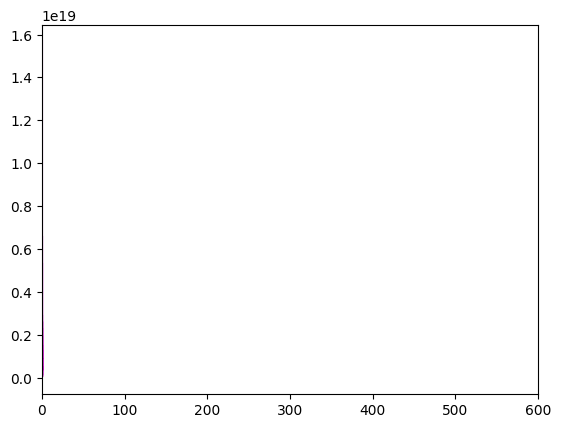

In [31]:
p_ave= np.mean(p, axis=0)
p_ave2= np.mean(p2, axis=0)
p_ave3= np.mean(p3, axis=0)
plt.plot(tau, np.abs(p_ave),'k')
plt.plot(tau, np.abs(p_ave2),'m')
plt.plot(tau, np.abs(p_ave3),'g')
# plt.plot(tau, np.abs(p[0,:]),'k')
plt.xlim([0,600])


In [16]:
# for key in cal_data_gleam[0].keys():
#     plt.semilogy(freqs,  np.abs(cal_data_gleam[0][key][0,:]))
# plt.semilogy(freqs,np.abs(cross_all_time)[0,:],'k')

## Gain analysis

In [17]:
def extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for i in range (N):
        g1=np.load(path_data+gain_name+uvh5name[4*i][43:69]+".npy",allow_pickle=True).item()
        gain_temp=[]
        for ant in g1:
            for t in range (1):
                gain_temp.append(g1[ant][t,:])
        gain_temp=np.array(gain_temp)
        gain_ave=np.mean(np.abs(gain_temp), axis=0)
        gains_gleam.append(gain_ave)
    gains_gleam=np.array(gains_gleam) 

    return gains_gleam
    
gains_gleam=extract_antenna_averaged_gains(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_gleam_filter=extract_antenna_averaged_gains(gain_name="gains/gains_Notch_filter_40_mHz_gleam_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full=extract_antenna_averaged_gains(gain_name="gains/gains_full_flagged_abscal", N=N,uvh5name=uvh5name)
gains_full_filter=extract_antenna_averaged_gains(gain_name="gains/gains_Notch_filter_40_mHz_full_flagged_abscal", N=N,uvh5name=uvh5name)

In [18]:
N=275

def extract_antenna_gains_all_times(gain_name="gains/gains_gleam_flagged_abscal", N=N,uvh5name=uvh5name):
    gains_gleam =[]
    for i in range (N):
        g1=np.load(path_data+gain_name+uvh5name[i]+".npy",allow_pickle=True).item()
        
        for ant in g1:
            gain_temp=[]
            for t in range (2):
                gain_temp.append(g1[ant][t,:])
            gain_temp=np.array(gain_temp)
            gains_gleam.append(np.mean(gain_temp,axis=0))
    gains_gleam=np.array(gains_gleam) 

    return gains_gleam    

def produce_plots_every_n_time(n=10, N=N, gains=gains_gleam):
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    plt.figure(figsize=(5,2))
                plt.plot(freqs[50:-1],gains[i,:][50:-1])
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")

def produce_plots_colour_every_n_time(n=10, N=N, gains=gains_gleam):
    cl_al=[c['color'] for c in plt.rcParams['axes.prop_cycle']]
    for m in range (int(N/n)):
        for i in range (N):
        
            if n*m<=i and i<(m+1)*n:
                if i==m*n:
                    #plt.figure(figsize=(5,2))
                    cl=cl_al[m]
                plt.plot(freqs[50:-1],gains[i,:][50:-1], cl)
                plt.xlabel("Freqs [MHz]")
                plt.ylabel("|g|")                
        
def produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam, lsts=lsts):
    for m in range (int(N/n)):
        gain_temp=[]
        for i in range (N):
            
            if n*m<=i and i<(m+1)*n:
                
                if i==m*n:
                    gain_temp.append(gains[i,:][50:-1])
        gain_temp=np.array(gain_temp)
        gains_ave=np.mean(gain_temp, axis=0)
                
        plt.plot(freqs[50:-1],gains_ave, label="lst ="+str(np.round(lsts[m*n],2)))    
        plt.xlabel("Freqs [MHz]")
        plt.ylabel("|g|")
        plt.legend()

# Extract gains

## Plots gains every 10*20s

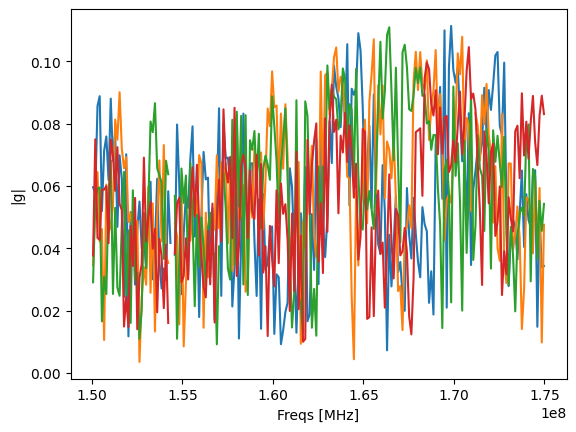

In [19]:
index=np.where((2<lsts) & (lsts<2.1))
for i in range (len(index[0])):
    plt.plot(freqs,gains_gleam[index[0][i],:], label="lst ="+str(np.round(lsts[index],2)))    
    plt.xlabel("Freqs [MHz]")
    plt.ylabel("|g|")
    # plt.legend()

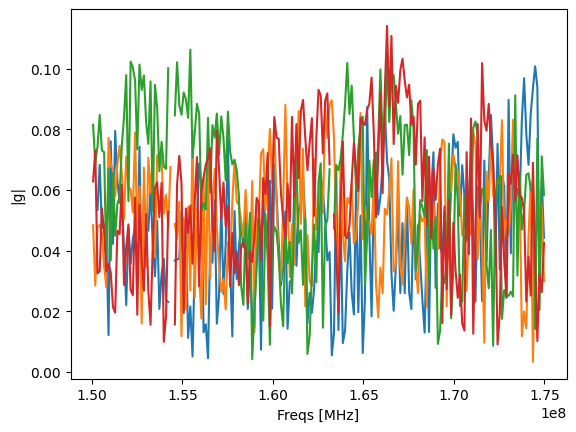

In [20]:
index=np.where((0<lsts) & (lsts<0.1))
for i in range (len(index[0])):
    plt.plot(freqs,gains_gleam[index[0][i],:], label="lst ="+str(np.round(lsts[index],2)))    
    plt.xlabel("Freqs [MHz]")
    plt.ylabel("|g|")
    # plt.legend()

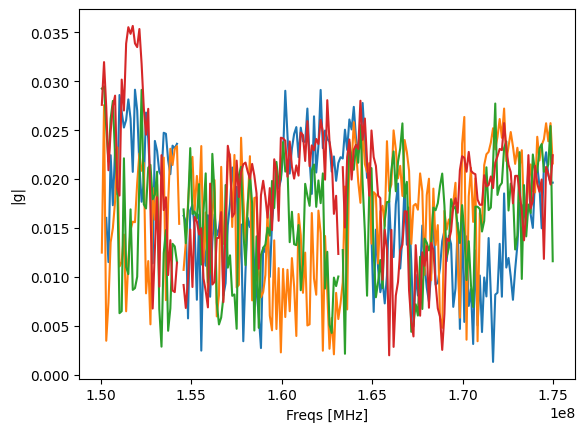

In [21]:
index=np.where((0<lsts) & (lsts<0.1))
for i in range (len(index[0])):
    plt.plot(freqs,gains_full[index[0][i],:], label="lst ="+str(np.round(lsts[index],2)))    
    plt.xlabel("Freqs [MHz]")
    plt.ylabel("|g|")

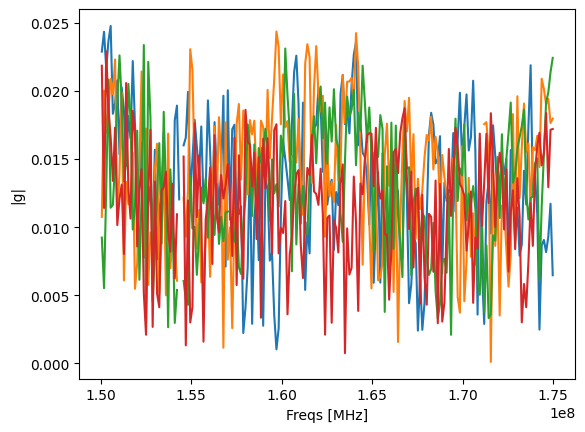

In [22]:
index=np.where((2<lsts) & (lsts<2.1))
for i in range (len(index[0])):
    plt.plot(freqs,gains_full[index[0][i],:], label="lst ="+str(np.round(lsts[index],2)))    
    plt.xlabel("Freqs [MHz]")
    plt.ylabel("|g|")

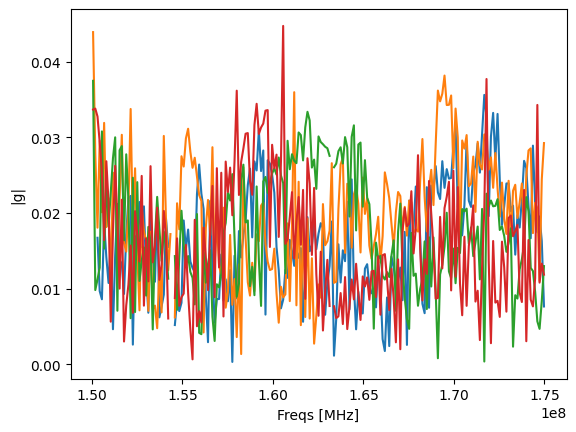

In [23]:
index=np.where((0<lsts) & (lsts<0.1))
for i in range (len(index[0])):
    plt.plot(freqs,gains_full_filter[index[0][i],:], label="lst ="+str(np.round(lsts[index],2)))    
    plt.xlabel("Freqs [MHz]")
    plt.ylabel("|g|")

In [24]:
gains_gleam.shape

(275, 205)

In [41]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam)

In [42]:

# produce_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter)

In [43]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full)

In [44]:
# produce_plots_every_n_time(n=10, N=N, gains=gains_full_filter)

## Plot average over with colour

IndexError: list index out of range

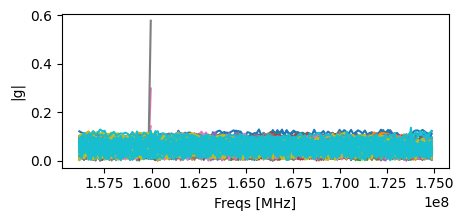

In [125]:
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_gleam)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_gleam_filter)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_full)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_full_filter)

IndexError: list index out of range

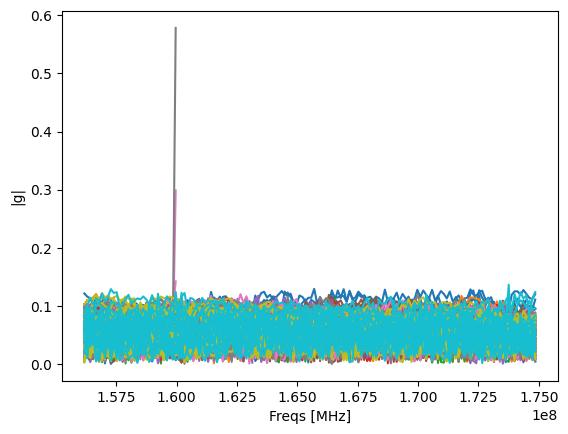

In [126]:
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_gleam)
plt.figure(figsize=(5,2))
produce_plots_colour_every_n_time(n=20, N=N, gains=gains_gleam_filter)

In [47]:
len(lsts)

275

## Average gains over 10n

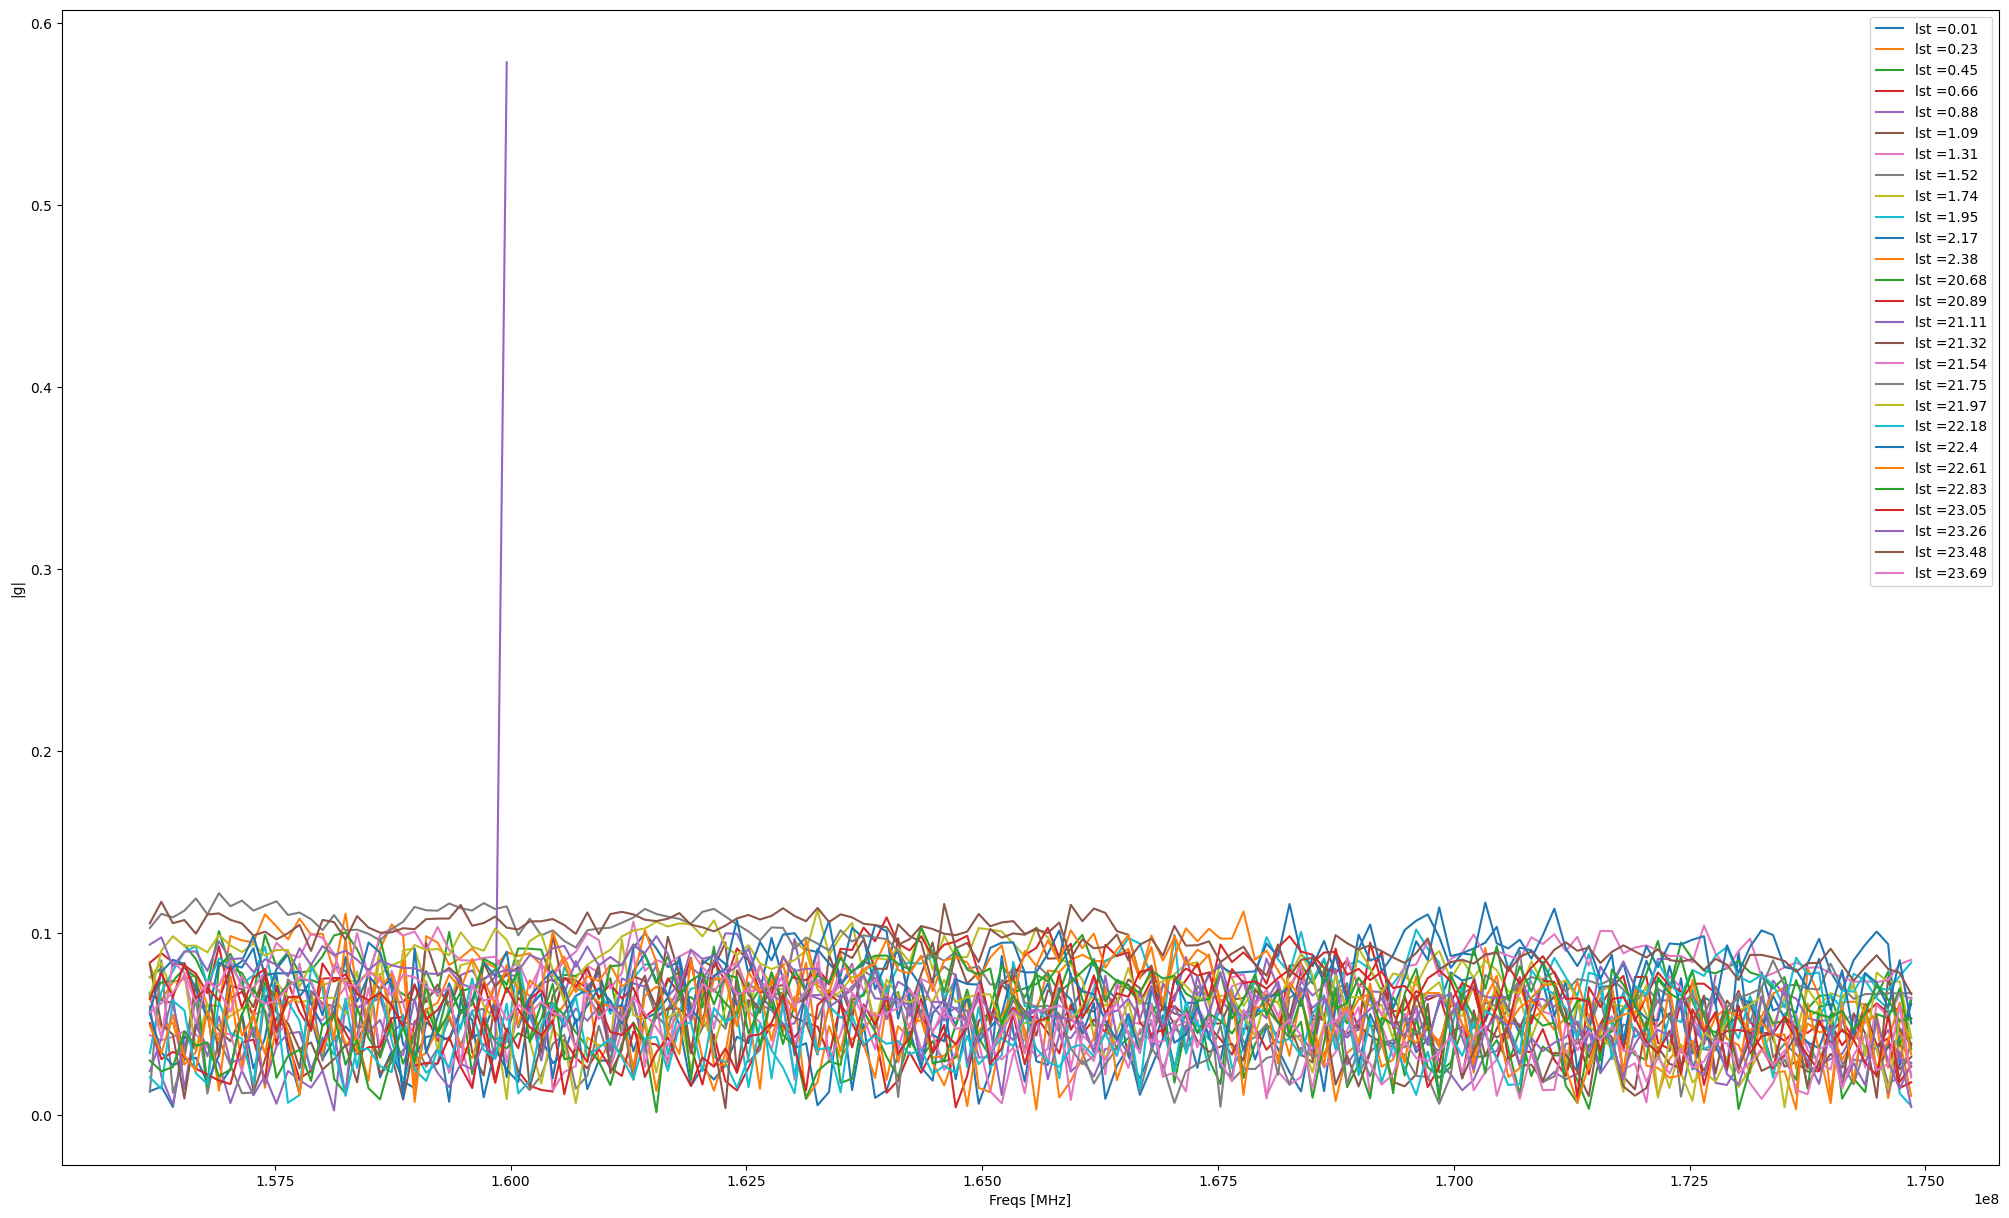

In [48]:
plt.figure(figsize=(25,15))
produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_full, lsts=lsts)

# plt.figure(figsize=(5,2))
# produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter, lsts=lsts)

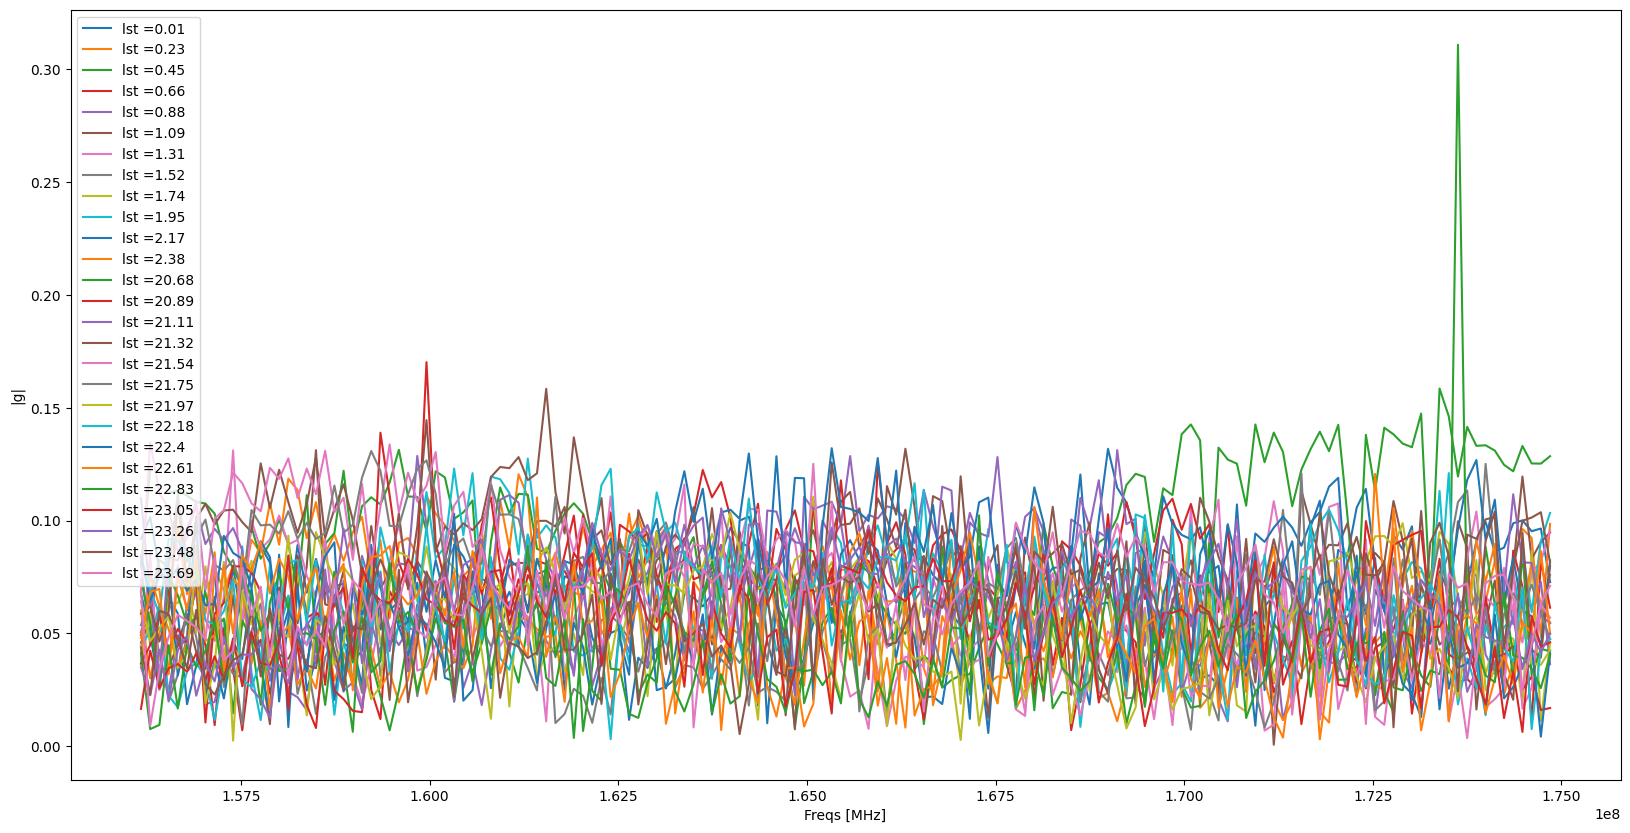

In [49]:

plt.figure(figsize=(20,10))
produce_average_plots_every_n_time(n=10, N=N, gains=gains_gleam_filter, lsts=lsts)

# Subset of freqs

Text(0, 0.5, '|g|')

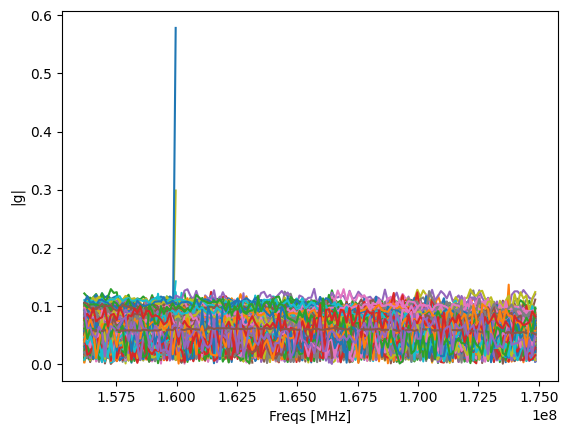

In [50]:

for i in range (gains_gleam.shape[0]):
    plt.plot(freqs[50:-1],np.abs(gains_gleam[i,50:-1]))

plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam[:,50:-1]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

In [51]:
gains_gleam.shape

(275, 205)

Text(0, 0.5, '|g|')

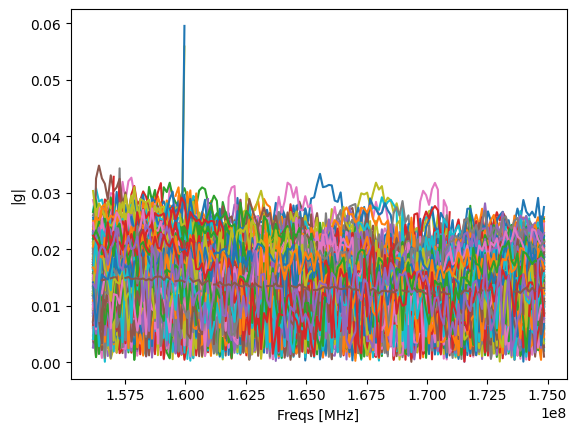

In [52]:

for i in range (gains_full.shape[0]):
    plt.plot(freqs[50:-1],np.abs(gains_full[i,50:-1]))

plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_full[:,50:-1]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

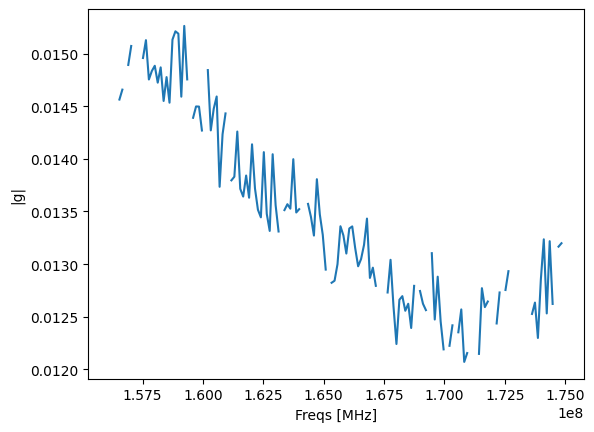

In [53]:
for i in range (gains_full.shape[0]-15000):
    plt.plot(freqs[50:-1],np.abs(gains_full[i,50:-1]))

plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_full[:,50:-1]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

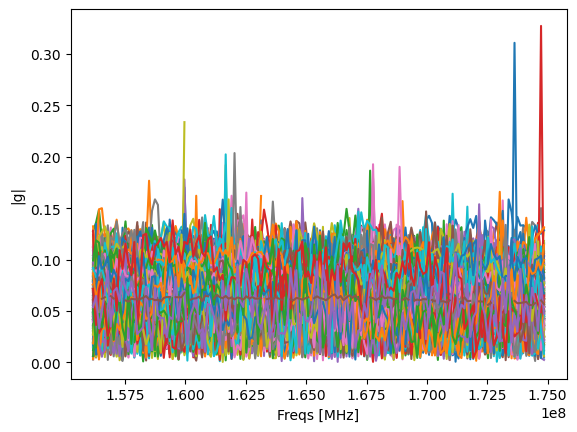

In [54]:

for i in range (gains_gleam_filter.shape[0]):
    plt.plot(freqs[50:-1],np.abs(gains_gleam_filter[i,50:-1]))

plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam_filter[:,50:-1]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

Text(0, 0.5, '|g|')

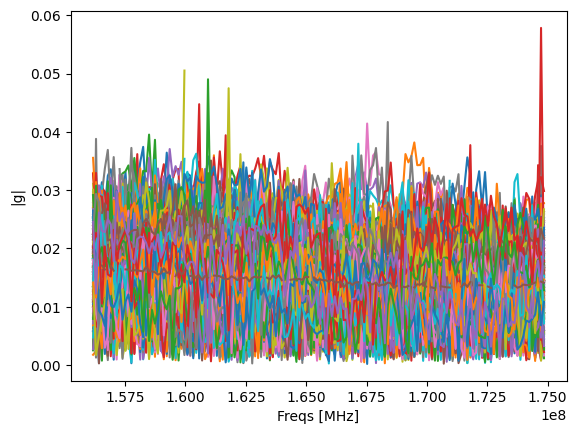

In [55]:

for i in range (gains_full_filter.shape[0]):
    plt.plot(freqs[50:-1],np.abs(gains_full_filter[i,50:-1]))

plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_full_filter[:,50:-1]), axis=0)))  
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")

## Avarage gain amplitude

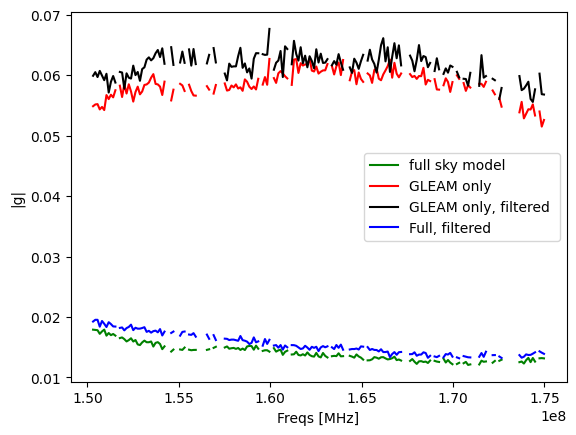

In [26]:
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full[:,:]), axis=0)),'g', label="full sky model") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam[:,:]), axis=0)),'r', label="GLEAM only") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_gleam_filter[:,:]), axis=0)),'k', label="GLEAM only, filtered ") 
plt.plot(freqs,np.abs(np.mean(np.abs(gains_full_filter[:,:]), axis=0)),'b', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

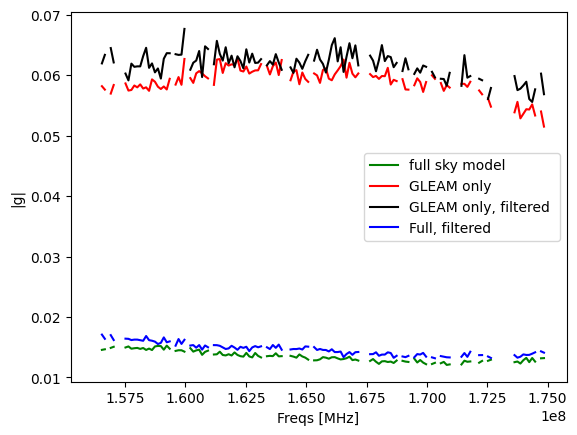

In [27]:
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_full[:,50:-1]), axis=0)),'g', label="full sky model") 
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam[:,50:-1]), axis=0)),'r', label="GLEAM only") 
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_gleam_filter[:,50:-1]), axis=0)),'k', label="GLEAM only, filtered ") 
plt.plot(freqs[50:-1],np.abs(np.mean(np.abs(gains_full_filter[:,50:-1]), axis=0)),'b', label="Full, filtered ") 
plt.xlabel("Freqs [MHz]")
plt.ylabel("|g|")
plt.legend()

## Delay Transform average gain

In [47]:
def fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[:,50:-1]):

    gains=np.abs(gains_raw)
    tau=np.fft.fftshift(np.fft.fftfreq(len(freqs),np.abs(freqs[1]-freqs[0])))*1e9
    index=np.where(tau>0)
    tau_pos=tau[index]
    window=np.ones(gains.shape)
    for i in range(window.shape[0]):
        window[i,:]=windows.blackmanharris(len(freqs))
    
   
    gains_full_fitted=[]
    for t in range (gains.shape[0]):
        gains_time_no_nans=gains[t,:][~np.isnan(gains[t,:])]
        freq_no_nans=freqs[~np.isnan(gains[t,:])]
        coeffs = np.polyfit(freq_no_nans, gains_time_no_nans, 6)
        poly = np.poly1d(coeffs)
        x_fit=freqs
        y_fit=poly(x_fit)
        gains_fitted=[]
        for i in range (gains.shape[1]):
            if np.isnan(gains[t,i]):
                gains_fitted.append(poly(x_fit[i]))
            else:
                gains_fitted.append(gains[t,i])
        gains_fitted=np.array(gains_fitted)

        gains_full_fitted.append(gains_fitted)
    gains_full_fitted=np.array(gains_full_fitted)
    g0_delay=np.mean(np.fft.fftshift(np.abs(np.fft.fft(window*gains_full_fitted))),axis=0)[index]
    
    return np.mean(gains_full_fitted, axis=0), gains_full_fitted, g0_delay, tau_pos





In [52]:
def produce_plots_delay(n,N):
    gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[n:N,50:-1])
    gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[n:N,50:-1])
    gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam_filter[n:N,50:-1])
    gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full_filter[n:N,50:-1])
    
    plt.plot(freqs[50:-1], gains_full_ave,'k', label="full")
    plt.plot(freqs[50:-1], gains_gleam_ave, 'r', label="gleam")
    plt.plot(freqs[50:-1], gains_gleam_filter_ave, 'g', label="gleam filter")
    plt.plot(freqs[50:-1], gains_full_filter_ave, 'm', label="full filter")
    plt.xlabel("Freq[MHz]")
    plt.legend()
    plt.figure()
    plt.semilogy(tau_pos, full_delay/np.max(full_delay),'k')
    plt.semilogy(tau_pos, gleam_delay/np.max(gleam_delay),'r')
    plt.semilogy(tau_pos, gleam_filter_delay/np.max(gleam_filter_delay),'g')
    plt.semilogy(tau_pos, full_filter_delay/np.max(full_filter_delay),'m')
    
    plt.xlim([0,2500])

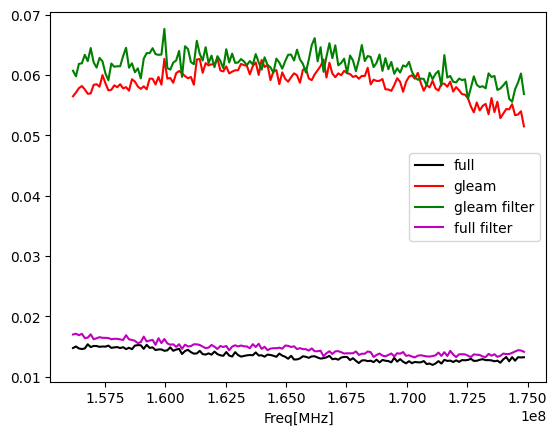

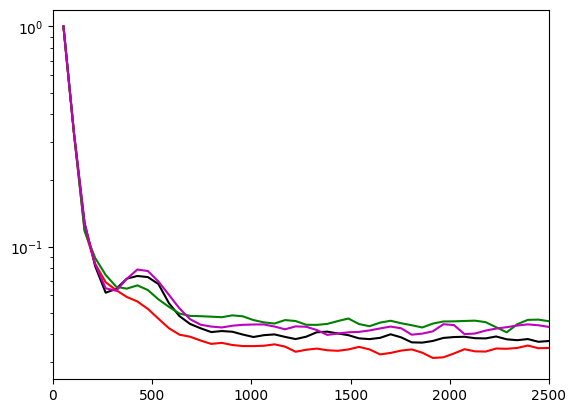

In [56]:
produce_plots_delay(n=0,N=275)

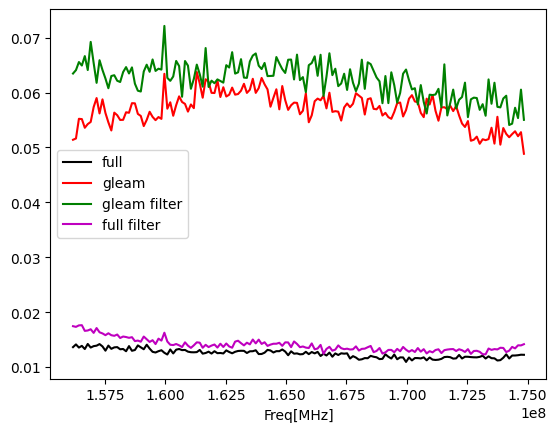

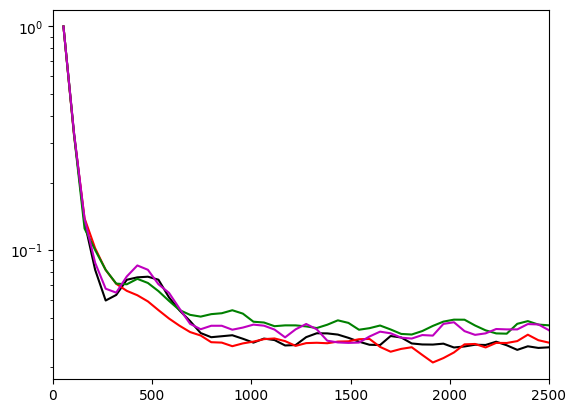

In [60]:
produce_plots_delay(n=75,N=200)

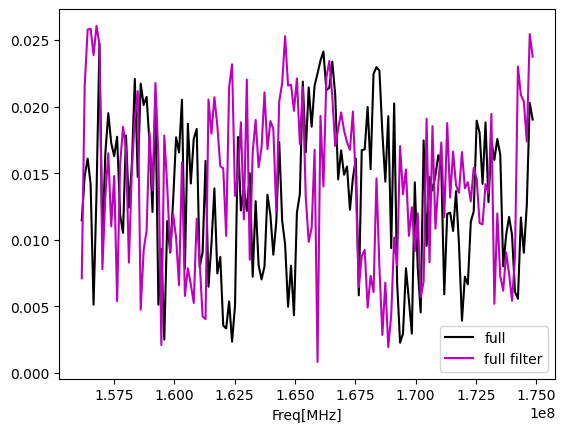

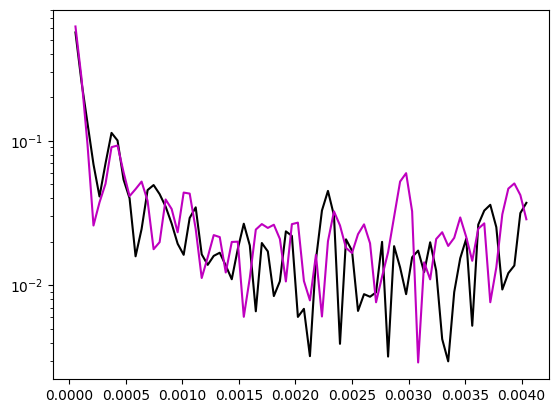

In [121]:
produce_plots_delay(n=90,N=91)

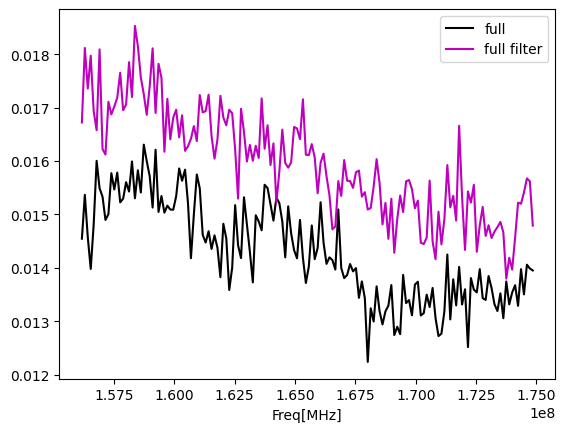

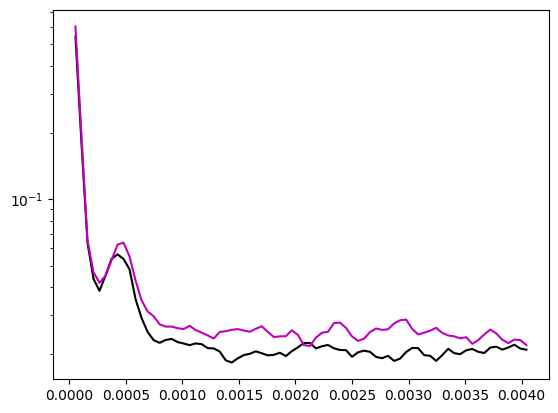

In [122]:
produce_plots_delay(n=0,N=100)

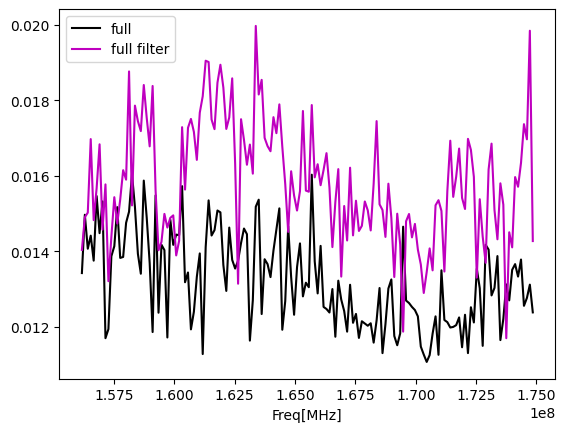

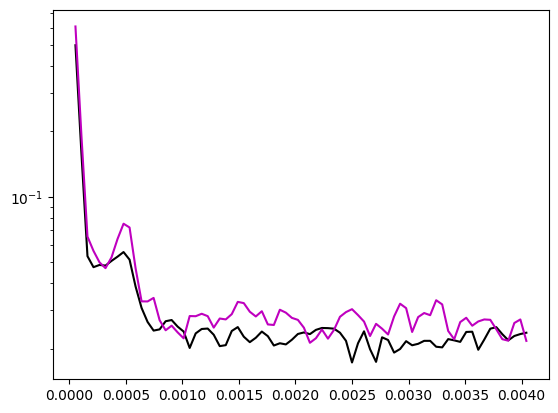

In [123]:
produce_plots_delay(n=50,N=70)

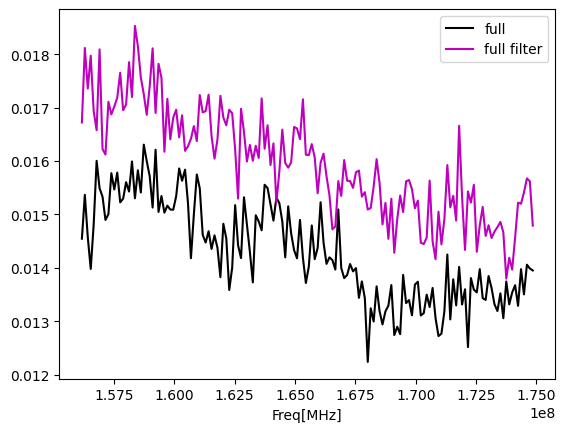

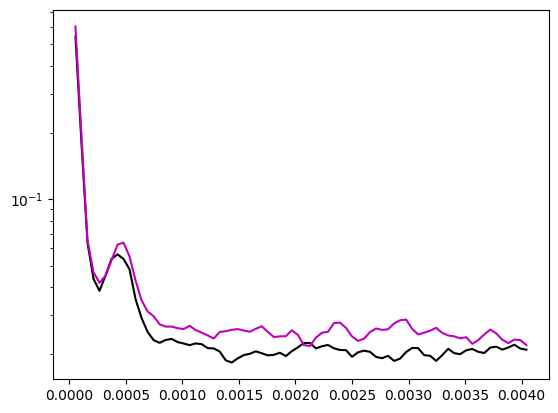

In [124]:
produce_plots_delay(n=0,N=100)

In [77]:
gains_full_ave, g0, full_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full[90:100,50:-1])
gains_gleam_ave, g1, gleam_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam[90:100,50:-1])
gains_gleam_filter_ave, g2, gleam_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_gleam_filter[90:100,50:-1])
gains_full_filter_ave, g3, full_filter_delay, tau_pos=fit_gains_and_perform_delay_trans(freqs=freqs[50:-1], gains_raw=gains_full_filter[90:100,50:-1])


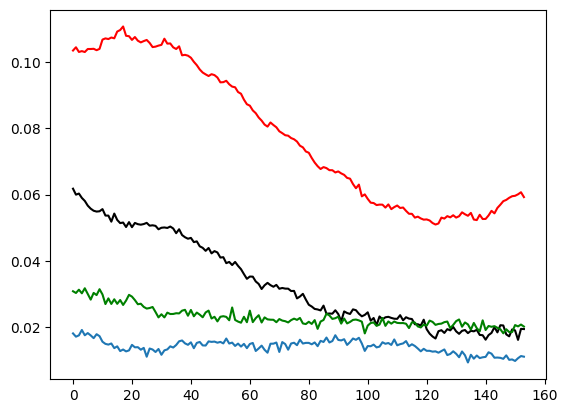

In [78]:
plt.plot(gains_full_ave,'k')
plt.plot(gains_gleam_ave, 'r')
plt.plot(gains_gleam_filter_ave, 'g')
plt.plot(gains_full_filter_ave)

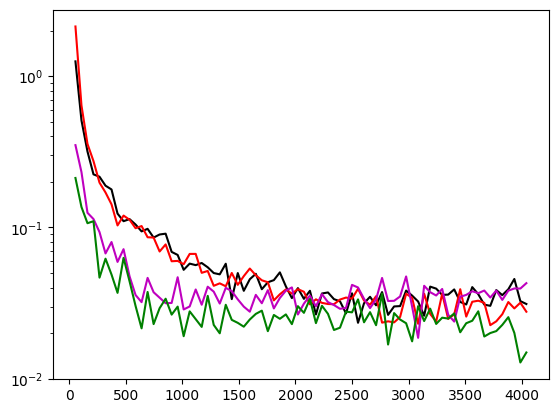

In [79]:
plt.semilogy(tau_pos, full_delay,'k')
plt.semilogy(tau_pos, gleam_delay,'r')
plt.semilogy(tau_pos, gleam_filter_delay,'m')
plt.semilogy(tau_pos, full_filter_delay,'g')
# plt.xlim([0,5000])

## Chis-sqaure

In [1]:
N=90
chis_no_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_redcal_"+uvh5name[i]+".npy")

    chis_no_filer.append(g1)
chis_no_filer=np.array(chis_no_filer) 

NameError: name 'np' is not defined

In [62]:
chis_filer =[]
for i in range (N):
    i=i+1
    g1=np.load(path_data+"chisq/chisq_Notch_filter_40_mHz_redcal_"+uvh5name[i]+".npy")

    chis_filer.append(g1)
chis_filer=np.array(chis_filer) 

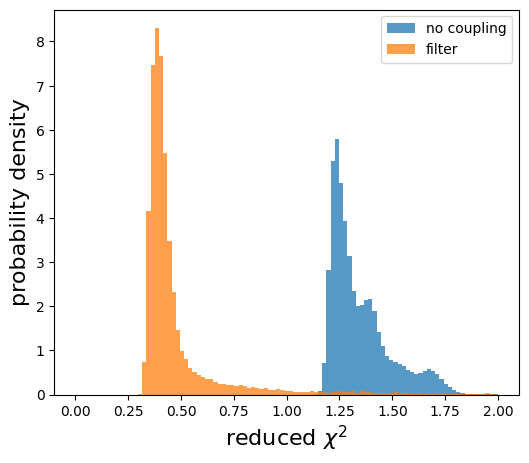

In [63]:
plt.figure(figsize=(6, 5))
plt.hist(np.abs(chis_no_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="no coupling")
plt.hist(np.abs(chis_filer.ravel()), bins=101, range=(0, 2), density=True, alpha=0.75,label="filter")
x = np.linspace(0.8, 1.2, 1000)
#plt.plot(x, stats.chi2.pdf(x * 2*dof, 2*dof) * 2*dof, c='k', ls='--', lw=2,label="$\chi_k^2$ (kx)/k ")
plt.xlabel(r'reduced $\chi^2$', fontsize=16)
plt.ylabel('probability density', fontsize=16)
plt.legend()

In [9]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [12]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [13]:
pol=hd.polarization_array

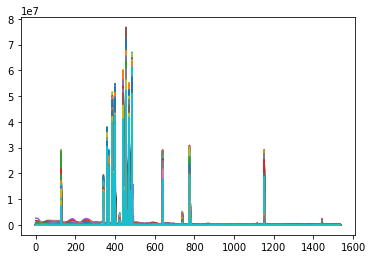

In [14]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [21]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [22]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



divide by zero encountered in log
divide by zero encountered in log
invalid value encountered in exp


In [23]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




invalid value encountered in true_divide
invalid value encountered in greater
invalid value encountered in greater


In [24]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

AttributeError: 'dict' object has no attribute 'gains'

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [27]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


KeyError: "Unable to open object (object 'phase_type' doesn't exist)"

In [69]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

Selected 134 data baselines and 134 model baselines to load.


In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [28]:
hc.abscal.post_redcal_abscal??

Signature:
hc.abscal.post_redcal_abscal(
    model,
    data,
    data_wgts,
    rc_flags,
    edge_cut=0,
    tol=1.0,
    kernel=(1, 15),
    phs_max_iter=100,
    phs_conv_crit=1e-06,
    verbose=True,
)
Source:   
def post_redcal_abscal(model, data, data_wgts, rc_flags, edge_cut=0, tol=1.0, kernel=(1, 15),
                       phs_max_iter=100, phs_conv_crit=1e-6, verbose=True):
    '''Performs Abscal for data that has already been redundantly calibrated.

    Arguments:
        model: DataContainer containing externally calibrated visibilities, LST-matched to the data.
            The model keys must match the data keys.
        data: DataContainer containing redundantly but not absolutely calibrated visibilities. This gets modified.
        data_wgts: DataContainer containing same keys as data, determines their relative weight in the abscal
            linear equation solvers.
        rc_flags: dictionary mapping keys like (1, 'Jnn') to flag waterfalls from redundant calibratio